<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK9_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 9 — Utility Evaluation: TSTR and Analytical Replicability**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

---

## Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB8 | Fidelity and inter-replica stability evaluation |
| NB9 | Utility evaluation: TSTR, replicability framework |
| **NB10** | **Privacy evaluation: re-identification risk** |

---

## Objectives

Evaluates the downstream utility of synthetic data generated by CTAB-GAN+ (NB6)
and ARF/FORDE (NB7) through:

1. **pMSE** — general distinguishability metric (Miletic & Sariyar 2025)
2. **VIF replication** — multicollinearity structure preservation
3. **AIC/BIC backward selection agreement** — variable selection replication
4. **Coefficient table + CI overlap** — effect estimate replicability
5. **El Emam replicability framework** — 8 metrics with Rubin combining rules
6. **Correlation distances + VIMP** — structural and feature-importance fidelity
7. **TSTR risk scoring system** — full NB4 pipeline trained on synthetic, tested on real
8. **Comparative summary** — CTAB-GAN+ vs. ARF

All analyses are conditioned on a single outcome (`TARGET_COL`) and generator
(`GENERATOR`), configured in Cell 2.

> **Design principle:** One execution = one outcome = one generator.
> Switch `TARGET_COL` and `GENERATOR` in the configuration cell and re-run.

## **1. Configuration**

In [ ]:
# ── LIBRARIES ────────────────────────────────────────────────────────────────
import os
import json, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
import seaborn as sns

from scipy import stats
from scipy.stats import chi2
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     GridSearchCV)
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve,
                             classification_report)
from sklearn.calibration import calibration_curve as sklearn_calibration_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries loaded.")

# ── Google Drive mount (Colab) ────────────────────────────────────────────────
try:
    from google.colab import drive
    from pathlib import Path
    if not Path('/content/drive').exists():
        drive.mount('/content/drive')
    print("Google Drive mounted.")
except ImportError:
    print("Not running in Colab — skipping Drive mount.")

Libraries loaded.
Google Drive mounted.


In [ ]:
# ── GLOBAL CONFIGURATION ─────────────────────────────────────────────────────
# Change these two lines to switch outcome / generator.
# Everything else is derived automatically.
TARGET_COL = 'Mort. 30D'   # 'Mort. 2D' | 'Mort. 7D' | 'Mort. 30D'
GENERATOR  = 'ARF'     # 'CTABGAN'  | 'ARF'

N_REPLICAS = 10            # number of replica datasets to load

# ── REAL TRAINING SPLIT SOURCE ────────────────────────────────────────────────
# NB9 uses the real train/test split exported by the synthetic-generation
# pipeline. The real training partition is reconstructed by concatenating the
# cohort files stored in GENERATION/DATASET_<GENERATOR>/cohorts/.
# This avoids mixing a global split from dataset_FINAL.csv with the
# generator-specific test set.
COHORTS_SUBDIR = 'cohorts'
COHORT_FILES = [
    'cohort_Mort_2D.csv',
    'cohort_Mort_7D.csv',
    'cohort_Mort_30D.csv',
    'cohort_survivors.csv',
]

# ── REPRESENTATIVE REPLICA ───────────────────────────────────────────────────
# Used for β-rounding diagnostics (8b).  None → auto-select the replica
# whose AUC-ROC is closest to the median across all replicas.
# Override with a string key (e.g. 'ds05') to pin to a specific replica.
REPRESENTATIVE_REPLICA = None

# ── FEATURE SETS (exact copy from NB4 Section 2 — FEATURES_PER_OUTCOME) ─────
# These must match NB4 exactly.  Any change here would make TSTR comparisons
# invalid because the binning, OHE columns and coefficient indexing differ.
FEATURES_PER_OUTCOME = {
    "Mort. 2D":  ["Edad", "GCS", "Lactato", "FR", "SpO2","TAM", "Resrv."],
    "Mort. 7D":  ["Edad", "GCS", "Lactato", "SpO2", "TT", "TAM", "FR", "Resrv.", "VAD"],
    "Mort. 30D": ["Edad", "GCS", "Lactato", "SpO2", "Resrv.", "IOT", "VAD", "FR"],
}
FEATURES = FEATURES_PER_OUTCOME[TARGET_COL]

# ── VARIABLE TYPING (mirrors NB4 Section 2) ─────────────────────────────────
BINARY_VARS = {'Resrv.', 'IOT', 'VAD'}
GCS_VARS    = {'GCS'}
GCS_LEVELS  = list(range(3, 16))   # 3, 4, ..., 15

# pd.cut convention copied from NB4. These variables use left-closed bins
# such as [90, 94) rather than right-closed bins such as (90, 94].
RIGHT_TRUE_VARS  = {"Edad", "Lactato", "FR", "Glucemia"}
RIGHT_FALSE_VARS = {"SpO2", "TT", "FC","TAM", "TAS", "TAD"}

# ── CLINICAL CUTPOINTS (exact copy from NB4 Section 2 — CLINICAL_CUTS_PER_OUTCOME) ─
# These cutpoints are FIXED from NB4 and must NOT be re-estimated on synthetic
# data.  This ensures that TSTR performance differences reflect synthetic data
# quality, not model redesign.
CLINICAL_CUTS_PER_OUTCOME = {
      "Mort. 2D": {
        "Edad":    [55.0, 70.0, 85.0],
        "Lactato": [3.5, 6.0],
        "TT":      [35.5, 37.5],#Not employed
        "FR":      [14, 22, 28],
        "SpO2":    [90.0, 94.0],
        "TAM":     [70, 110],
    },
    "Mort. 7D": {
        "Edad":    [58.0, 72.0, 85.0],
        "Lactato": [3.5, 6.0],
        "SpO2":    [90.0, 94.0],
        "TT":      [35.5, 37.5],
        "FR":      [14, 22, 28],
        "TAM":     [70, 110],
    },
    "Mort. 30D": {
        "Edad":    [58.0, 72.0, 85.0],
        "Lactato": [3.5, 6.0],
        "FR":      [14.0, 22.0, 28.0],
        "SpO2":    [90.0, 94.0],
        "TT":      [35.5, 37.5],#Not employed
        "FC":      [60, 100, 120],#Not employed
    },
}
CLINICAL_CUTS = CLINICAL_CUTS_PER_OUTCOME[TARGET_COL]
ROUND_THRESHOLD = 0.45   # β-rounding threshold
CLIP_NEGATIVE   = True  # Must match NB4 selection.
                         # False preserves negative point values and keeps
                         # the score comparable with the NB4 reference scale.

# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/TFG/GENERATION'
BASE_GEN = {
    'CTABGAN': os.path.join(BASE_DIR, 'DATASET_CTABGAN'),
    'ARF':     os.path.join(BASE_DIR, 'DATASET_ARF'),
}
SYNTH_FILENAME = {
    'CTABGAN': 'dataset_SYNTH_CTABGAN.csv',
    'ARF':     'dataset_SYNTH_ARF.csv',
}

TARGET_SAFE = TARGET_COL.replace('.', '').replace(' ', '')
OUTPUT_DIR  = (f'/content/drive/MyDrive/Colab Notebooks/TFG/EVALUATION/'
               f'NB9_UTILITY/{GENERATOR}_{TARGET_SAFE}/')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Target outcome : {TARGET_COL}")
print(f"  Generator      : {GENERATOR}")
print(f"  Features       : {FEATURES}")
print(f"  N replicas     : {N_REPLICAS}")
print(f"  Output dir     : {OUTPUT_DIR}")

Configuration:
  Target outcome : Mort. 30D
  Generator      : ARF
  Features       : ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD', 'FR']
  N replicas     : 10
  Output dir     : /content/drive/MyDrive/Colab Notebooks/TFG/EVALUATION/NB9_UTILITY/ARF_Mort30D/


In [ ]:
# ── TFG UNIFIED PLOT STYLE ────────────────────────────────────────────────────
"""
Matches the visual conventions of NB2, NB3, NB4:
white background, light grey grid, serif font, thin black border.
"""

# Aligned with NB8 TFG_STYLE for cross-notebook visual consistency.
TFG_STYLE = {
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    'black',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#d9d9d9',
    'grid.linewidth':    0.5,
    'grid.linestyle':    '-',
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Times New Roman', 'serif'],
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   9,
    'legend.frameon':    True,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'figure.dpi':        100,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
}
plt.rcParams.update(TFG_STYLE)

TFG_COLORS = {
    'primary':    '#2C5F8A',
    'secondary':  '#E07B39',
    'accent':     '#4CAF50',
    'neutral':    '#888888',
    'CTABGAN':    '#2C5F8A',
    'ARF':        '#E07B39',
}

print("Plot style set.")

Plot style set.


## **1. Data Loading**

### TSTR paradigm

- **Train on Synthetic (TS):** each synthetic replica (`dataset_SYNTH_*.csv`
  from `ds01/` … `ds10/`) is used as the training set. These assembled
  datasets contain both outcome classes for every `TARGET_COL`.
- **Test on Real (TR):** `dataset_TEST.csv` is the held-out real partition from
  the corresponding generation folder (`DATASET_ARF` or `DATASET_CTABGAN`).
  **No synthetic data ever enters the test set.**

### TRTR baseline and reference metrics

The real training set (`df_train`) is reconstructed from the cohort files
exported during synthetic data generation:

- `cohort_survivors.csv`
- `cohort_Mort_2D.csv`
- `cohort_Mort_7D.csv`
- `cohort_Mort_30D.csv`

These files are concatenated to reload the same real training partition used by
the selected generator. This avoids defining a new split inside NB9.

The resulting `df_train` is used only for:

1. The TRTR baseline (train-on-real, test-on-real)
2. Reference values for VIF, AIC selection, logistic coefficients, correlations
   and variable importance
3. Reference levels for the NB4 risk-score encoding

>The synthetic-generation notebooks used cohort-wise train/test splits: the test fraction was applied within each cohort and the resulting test subsets were then combined. Therefore, the real test size may differ slightly from a single global random 25% split.

>This is expected. The key TSTR requirement is that the real test set is not used to train the synthetic generator, fit the risk-score model, calibrate the score, or select decision thresholds. TRTR and TSTR are compared within the same generator-specific split.


In [ ]:
# ── DATA LOADING ──────────────────────────────────────────────────────────────
"""
PURPOSE: Load the three data sources needed for TSTR evaluation.

    1. Synthetic replicas (ds01/ … ds10/):  TSTR training sets.
    2. Real test set (dataset_TEST.csv):    generator-specific evaluation set.
    3. Real training cohorts (cohorts/*.csv): TRTR baseline + reference metrics.

The real training set is NOT reconstructed from dataset_FINAL.csv.  It is loaded
from the cohort files exported by the synthetic-generation pipeline, ensuring
that TRTR and TSTR use the same generator-specific real split.
"""

gen_base = BASE_GEN[GENERATOR]
fname    = SYNTH_FILENAME[GENERATOR]

required_cols = FEATURES + [TARGET_COL]


def _read_csv_clean(path):
    """Read a CSV and standardise column names."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)
    df.columns = df.columns.astype(str).str.strip()
    return df


def _select_required_columns(df, cols, label):
    """Select required columns with a clear error if any are missing."""
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {label}: {missing}")
    return df[cols].dropna(subset=[TARGET_COL]).copy()


# ── 1. Synthetic replicas (TSTR training sets) ───────────────────────────────
replicas = {}
for i in range(1, N_REPLICAS + 1):
    path = os.path.join(gen_base, f'ds{i:02d}', fname)
    df   = _read_csv_clean(path)
    df   = _select_required_columns(df, required_cols, f'synthetic replica ds{i:02d}')
    replicas[f'ds{i:02d}'] = df
    print(f"  ds{i:02d}: {len(df)} rows | "
          f"{df[TARGET_COL].mean()*100:.1f}% positive")

replica_list = list(replicas.values())

# ── 2. Real test set (generator-specific held-out partition) ─────────────────
test_path = os.path.join(gen_base, 'dataset_TEST.csv')
df_test   = _read_csv_clean(test_path)
df_test   = _select_required_columns(df_test, required_cols, 'real test set')
print(f"\nReal test set: {len(df_test)} rows | "
      f"{df_test[TARGET_COL].mean()*100:.1f}% positive")
print(f"Real test loaded from: {test_path}")

# ── 3. Real training set from generation cohorts ─────────────────────────────
cohorts_dir = os.path.join(gen_base, COHORTS_SUBDIR)
cohort_frames = []

print(f"\nLoading real training cohorts from: {cohorts_dir}")
for cohort_file in COHORT_FILES:
    cohort_path = os.path.join(cohorts_dir, cohort_file)
    df_c = _read_csv_clean(cohort_path)
    n_raw = len(df_c)
    df_c['_source_cohort'] = cohort_file.replace('.csv', '')
    cohort_frames.append(df_c)
    print(f"  {cohort_file}: {n_raw} rows")

df_train_raw = pd.concat(cohort_frames, axis=0).reset_index(drop=True)
df_train     = _select_required_columns(df_train_raw, required_cols, 'real training cohorts')

print(f"\nReal training set: {len(df_train)} rows | "
      f"{df_train[TARGET_COL].mean()*100:.1f}% positive")

# Optional transparency table before dropping helper column
if '_source_cohort' in df_train_raw.columns:
    print("\nTraining rows by exported cohort:")
    print(df_train_raw['_source_cohort'].value_counts().to_string())

# Sanity checks
for label, dset in [('df_train', df_train), ('df_test', df_test)]:
    n_classes = dset[TARGET_COL].nunique()
    assert n_classes >= 2, (
        f"ERROR: {label} has only {n_classes} class(es) for {TARGET_COL}.")

print("\n✓ Both classes present in df_train and df_test.")
print("✓ NB9 is using the generator-specific real split: training cohorts + dataset_TEST.csv.")


  ds01: 1781 rows | 10.9% positive
  ds02: 1781 rows | 10.9% positive
  ds03: 1781 rows | 10.9% positive
  ds04: 1781 rows | 10.9% positive
  ds05: 1781 rows | 10.9% positive
  ds06: 1781 rows | 10.9% positive
  ds07: 1781 rows | 10.9% positive
  ds08: 1781 rows | 10.9% positive
  ds09: 1781 rows | 10.9% positive
  ds10: 1781 rows | 10.9% positive

Real test set: 595 rows | 11.1% positive
Real test loaded from: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/dataset_TEST.csv

Loading real training cohorts from: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/cohorts
  cohort_Mort_2D.csv: 85 rows
  cohort_Mort_7D.csv: 44 rows
  cohort_Mort_30D.csv: 66 rows
  cohort_survivors.csv: 1586 rows

Real training set: 1781 rows | 10.9% positive

Training rows by exported cohort:
_source_cohort
cohort_survivors    1586
cohort_Mort_2D        85
cohort_Mort_30D       66
cohort_Mort_7D        44

✓ Both classes present in df_train and df_test.
✓ NB9 is using the g

## **2. pMSE - General Utility Metric**

The **Propensity Score Mean Squared Error (pMSE)** quantifies how well a classifier can distinguish synthetic from real data.

A Random Forest classifier is trained on the combined real training cohort and
one synthetic replica, using a binary label:

- `0 = real`
- `1 = synthetic`

For each sample, the estimated probability $\hat{p}_i$ of being synthetic is
obtained using **10-fold stratified cross-validation** with out-of-fold
predictions. This prevents overfitting of the propensity model.

Let:

$$
c = \frac{N_{\mathrm{synth}}}{N_{\mathrm{real}} + N_{\mathrm{synth}}}
$$

where $c$ is the expected probability of being synthetic under perfect
indistinguishability. The propensity mean squared error is then computed as:

$$
\mathrm{pMSE} =
\frac{1}{N}
\sum_{i=1}^{N}
\left(\hat{p}_i - c\right)^2
$$

The raw pMSE is normalised by its theoretical maximum, $c(1-c)$:

$$
\mathrm{pMSE}_{\mathrm{norm}} =
\frac{\mathrm{pMSE}}{c(1-c)}
\in [0, 1]
$$

Interpretation:

- **0** = indistinguishable synthetic and real data, ideal case.
- **1** = perfectly distinguishable synthetic and real data, worst case.

When the real and synthetic datasets have the same size, $c = 0.5$ and
$c(1-c) = 0.25$, which gives the commonly used balanced formula.

Ten folds are used for consistency with the number of synthetic replicas and
with the cross-validation strategy used in the risk-score modelling pipeline.


  ds01: pMSE = 0.3622
  ds02: pMSE = 0.3718
  ds03: pMSE = 0.3622
  ds04: pMSE = 0.3665
  ds05: pMSE = 0.3841
  ds06: pMSE = 0.3719
  ds07: pMSE = 0.3714
  ds08: pMSE = 0.3577
  ds09: pMSE = 0.3661
  ds10: pMSE = 0.3846

pMSE  mean ± SD : 0.3698 ± 0.0085
pMSE  range     : [0.3577, 0.3846]


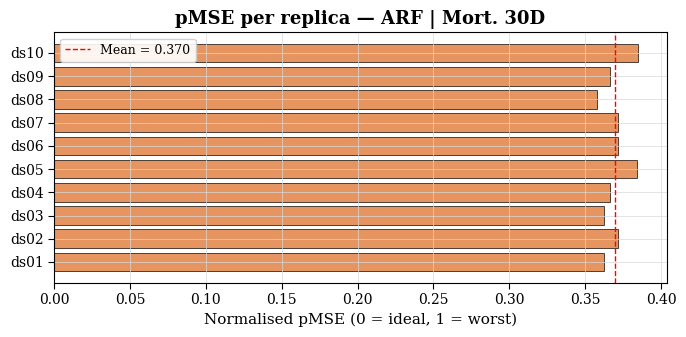

In [ ]:
# ── pMSE — GENERAL UTILITY ────────────────────────────────────────────────────
"""
PURPOSE: Compute normalised pMSE for each synthetic replica vs. real training data.

CONCEPT: If a classifier cannot distinguish synthetic from real, synthetic data
has high general utility. pMSE close to 0 is desirable.

NOTES:
- RandomForest with 10-fold stratified CV to obtain out-of-fold propensity scores.
- Only feature columns are used (not the outcome), to isolate distributional
  similarity from label information.
- Missing values in both real and synthetic data are imputed with medians learned
  from the real training data, avoiding replica-specific imputation artefacts.
- The expected propensity is the synthetic fraction c = n_synth / (n_real+n_synth),
  not necessarily 0.5. This keeps pMSE valid when dataset sizes differ.
"""

def compute_pmse(df_real, df_synth, features, n_splits=10):
    """Compute normalised propensity score MSE (pMSE).

    A Random Forest classifier is trained to distinguish real from synthetic
    records. Out-of-fold propensity scores are obtained via stratified CV.
    Lower values indicate the synthetic data is harder to distinguish from
    real data (better general utility).
    """
    real_medians = df_real[features].median(numeric_only=True)
    X_real  = df_real[features].fillna(real_medians)
    X_synth = df_synth[features].fillna(real_medians)

    X = pd.concat([X_real, X_synth], ignore_index=True)
    y = np.array([0] * len(X_real) + [1] * len(X_synth))

    c = len(X_synth) / max(len(X_real) + len(X_synth), 1)

    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    p_hat = cross_val_predict(clf, X, y, cv=skf, method='predict_proba')[:, 1]

    pmse = np.mean((p_hat - c) ** 2)
    denom = max(c * (1 - c), 1e-12)
    return pmse / denom

pmse_scores = {}
for key, df_s in replicas.items():
    pmse_scores[key] = compute_pmse(df_train, df_s, FEATURES)
    print(f"  {key}: pMSE = {pmse_scores[key]:.4f}")

pmse_vals = np.array(list(pmse_scores.values()))
print(f"\npMSE  mean ± SD : {pmse_vals.mean():.4f} ± {pmse_vals.std():.4f}")
print(f"pMSE  range     : [{pmse_vals.min():.4f}, {pmse_vals.max():.4f}]")

# Save
pd.DataFrame({'replica': list(pmse_scores.keys()),
              'pMSE_norm': pmse_vals}).to_csv(
    os.path.join(OUTPUT_DIR, 'pmse_results.csv'), index=False)

# Plot
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(list(pmse_scores.keys()), pmse_vals,
        color=TFG_COLORS[GENERATOR], alpha=0.8,
        edgecolor='black', linewidth=0.6)
ax.axvline(pmse_vals.mean(), color='red', linestyle='--', linewidth=1,
           label=f'Mean = {pmse_vals.mean():.3f}')
ax.set_xlabel('Normalised pMSE (0 = ideal, 1 = worst)')
ax.set_title(f'pMSE per replica — {GENERATOR} | {TARGET_COL}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pmse_barplot.png'), dpi=150)
plt.show()


## **3. VIF Replication**

VIF is recomputed on each synthetic replica using the same feature set as **NB4**. The goal is to verify whether the **multicollinearity structure** of the real training data is preserved in the synthetic datasets.

| VIF range | Interpretation |
|-----------|----------------|
| 1–2       | No collinearity |
| 2–5       | Moderate collinearity |
| > 5       | High collinearity — flagged |

### Inputs / Outputs

- **Input:** scaled continuous feature matrix per replica (same preprocessing as NB4)
- **Output:** per-replica VIF table; comparison bar chart against real-data VIF

### Interpretation of results

- VIF values similar to the real data: the synthetic generator correctly reproduces
  dependency structure among predictors.
- Systematically lower synthetic VIF: the generator has decorrelated the features,
  which will artificially inflate apparent predictor independence.
- Systematically higher synthetic VIF: the generator over-represents correlations,
  potentially shrinking coefficients through multicollinearity.

> **Caveat:** VIF is defined for continuous predictors via OLS auxiliary
> regressions.  Binary or ordinal variables included in the feature set are
> treated as numeric here (same convention as **NB4**); the result is an
> approximation for non-Gaussian variables.


VIF — Real training cohort:
  Edad           : 1.09
  GCS            : 1.96
  Lactato        : 1.19
  SpO2           : 1.58
  Resrv.         : 1.27
  IOT            : 1.65
  VAD            : 1.15
  FR             : 1.21

VIF synthetic (mean ± SD across 10 replicas):
  Edad           : 1.05 ± 0.01
  GCS            : 1.34 ± 0.06
  Lactato        : 1.13 ± 0.02
  SpO2           : 1.32 ± 0.04
  Resrv.         : 1.19 ± 0.04
  IOT            : 1.19 ± 0.04
  VAD            : 1.04 ± 0.02
  FR             : 1.08 ± 0.02


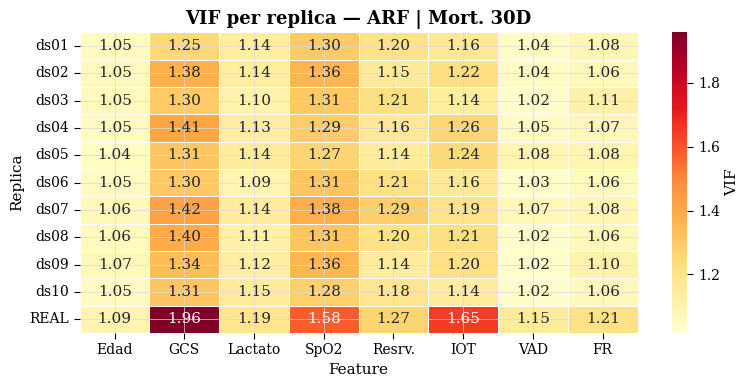

In [ ]:
# ── VIF REPLICATION ───────────────────────────────────────────────────────────
"""
PURPOSE: Replicate the VIF analysis of NB4 on each synthetic replica.

CONCEPT: VIF_j = 1 / (1 - R²_j), where R²_j is obtained by regressing feature j
on all other features.  VIF > 5 signals moderate multicollinearity.

OUTPUT: DataFrame with VIF per variable per replica; comparison with real-data VIF.
"""

def compute_vif(df, features):
    """Return VIF for each feature in the DataFrame."""
    X = df[features].copy()
    X = X.fillna(X.median())
    scaler = StandardScaler()
    X_sc   = pd.DataFrame(scaler.fit_transform(X), columns=features)
    X_sc   = sm.add_constant(X_sc)
    vif_vals = {feat: variance_inflation_factor(X_sc.values, i + 1)
                for i, feat in enumerate(features)}
    return vif_vals

# Compute VIF on real training cohort (reference)
vif_real = compute_vif(df_train, FEATURES)
print("VIF — Real training cohort:")
for k, v in vif_real.items():
    flag = ' ⚠ >5' if v > 5 else ''
    print(f"  {k:15s}: {v:.2f}{flag}")

# Compute VIF on each replica
vif_records = []
for key, df_s in replicas.items():
    vif_s = compute_vif(df_s, FEATURES)
    vif_s['replica'] = key
    vif_records.append(vif_s)

vif_df = pd.DataFrame(vif_records).set_index('replica')
vif_df.loc['REAL'] = vif_real

# Summary
vif_synth_only = vif_df.drop('REAL')
print(f"\nVIF synthetic (mean ± SD across {N_REPLICAS} replicas):")
for feat in FEATURES:
    m = vif_synth_only[feat].mean()
    s = vif_synth_only[feat].std()
    flag = ' ⚠' if m > 5 else ''
    print(f"  {feat:15s}: {m:.2f} ± {s:.2f}{flag}")

vif_df.to_csv(os.path.join(OUTPUT_DIR, 'vif_results.csv'))

# Heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(vif_df[FEATURES].astype(float), annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.4, ax=ax,
            cbar_kws={'label': 'VIF'})
ax.set_title(f'VIF per replica — {GENERATOR} | {TARGET_COL}')
ax.set_xlabel('Feature')
ax.set_ylabel('Replica')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vif_heatmap.png'), dpi=150)
plt.show()

## **4. AIC Backward Stepwise Selection**

AIC backward selection, matching the **NB4** variable-selection logic, is applied to the real training cohort and to each synthetic replica:

1. Fit the full logistic regression model with all variables in `FEATURES`.
2. Iteratively remove the variable whose removal gives the largest AIC improvement.
3. Stop when no removal improves AIC.

The **inclusion frequency** of each variable is the proportion of synthetic
replicas that retain it. Agreement is assessed against the real-data AIC-selected
feature set computed in this notebook, not hard-coded.

### Inputs / Outputs

- **Input:** loaded `replicas`, `df_train`, `FEATURES`, `TARGET_COL`.
- **Output:** `aic_selection_frequency.csv`, containing inclusion frequency and
  whether each variable was retained in the real-data AIC model.

### Interpretation

A high inclusion frequency for variables retained by the real model suggests that
synthetic data preserve the feature-outcome relationships relevant to AIC-based
model selection. Variables with low inclusion frequency are less stable across
synthetic replicas.


Real-data AIC-selected variables: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD', 'FR']
  ds01: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'FR']
  ds02: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD']
  ds03: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD', 'FR']
  ds04: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD']
  ds05: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'FR']
  ds06: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'FR']
  ds07: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD']
  ds08: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD', 'FR']
  ds09: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'VAD', 'FR']
  ds10: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'IOT', 'VAD', 'FR']

AIC variable inclusion frequency across 10 replicas:
feature  frequency  in_real
   Edad        1.0     True
    GCS        1.0     True
Lactato        1.0     True
   SpO2        1.0     True
 Resrv.        1.0     

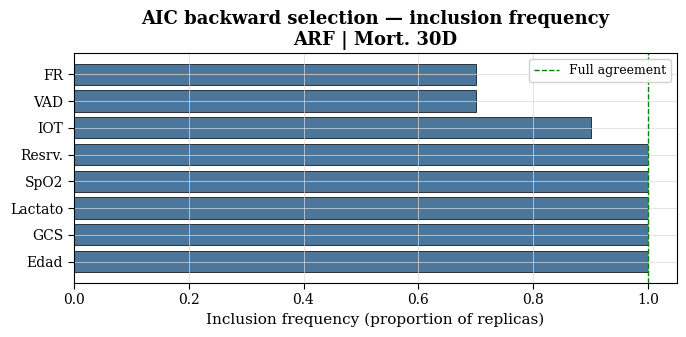

In [ ]:
# ── AIC BACKWARD STEPWISE ─────────────────────────────────────────────────────
"""
PURPOSE: Replicate AIC backward selection on each synthetic replica and compare
         it with the same AIC procedure applied to the real training cohort.

CONCEPT: Iteratively remove the variable whose removal most improves AIC until
no further improvement is possible. Tracks which variables survive selection
across replicas.

NOTES:
- Variables are treated atomically (no polychotomous dummies here; GCS enters
  as a single numeric variable for the backward selection step, consistent with
  NB4's pre-selection).
- StandardScaler is applied inside each fit to stabilise convergence, matching
  the NB4 approach.
"""

def backward_aic(df, features, outcome):
    """Return list of selected features after AIC backward stepwise."""
    remaining = features.copy()
    X = df[remaining + [outcome]].dropna()
    y = X[outcome].values

    while True:
        Xm  = sm.add_constant(
            StandardScaler().fit_transform(X[remaining]),
            has_constant='add')
        res = sm.Logit(y, Xm).fit(method='bfgs', disp=False, maxiter=200)
        best_aic = res.aic
        best_drop = None

        for feat in remaining:
            trial = [f for f in remaining if f != feat]
            if len(trial) == 0:
                continue
            Xt = sm.add_constant(
                StandardScaler().fit_transform(X[trial]),
                has_constant='add')
            try:
                rt  = sm.Logit(y, Xt).fit(method='bfgs', disp=False, maxiter=200)
                if rt.aic < best_aic:
                    best_aic  = rt.aic
                    best_drop = feat
            except Exception:
                continue

        if best_drop is None:
            break
        remaining.remove(best_drop)

    return remaining

# Real-data AIC-selected variables, computed with the same procedure.
REAL_SELECTED_AIC = backward_aic(df_train, FEATURES, TARGET_COL)
print(f"Real-data AIC-selected variables: {REAL_SELECTED_AIC}")

selection_counts = {f: 0 for f in FEATURES}
selection_log    = {}

for key, df_s in replicas.items():
    selected = backward_aic(df_s, FEATURES, TARGET_COL)
    selection_log[key] = selected
    for f in selected:
        selection_counts[f] += 1
    print(f"  {key}: {selected}")

# Inclusion frequency
freq_df = pd.DataFrame({
    'feature':   list(selection_counts.keys()),
    'frequency': [v / N_REPLICAS for v in selection_counts.values()],
    'in_real':   [f in REAL_SELECTED_AIC for f in selection_counts.keys()],
})
freq_df = freq_df.sort_values('frequency', ascending=False)
print(f"\nAIC variable inclusion frequency across {N_REPLICAS} replicas:")
print(freq_df.to_string(index=False))
freq_df.to_csv(os.path.join(OUTPUT_DIR, 'aic_selection_frequency.csv'), index=False)

# Plot
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = [TFG_COLORS['primary'] if r else TFG_COLORS['neutral']
          for r in freq_df['in_real']]
bars = ax.barh(freq_df['feature'], freq_df['frequency'],
               color=colors, edgecolor='black', linewidth=0.6, alpha=0.85)
ax.axvline(1.0, color='green', linestyle='--', linewidth=1, label='Full agreement')
ax.set_xlabel('Inclusion frequency (proportion of replicas)')
ax.set_title(f'AIC backward selection — inclusion frequency\n{GENERATOR} | {TARGET_COL}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'aic_inclusion_frequency.png'), dpi=150)
plt.show()


## **5. Coefficient Table — β, OR, p-values and CI Overlap**

Logistic regression coefficients (β), odds ratios (OR), 95 % confidence
intervals and p-values are extracted from each synthetic replica and compared
to the real-data model fitted on the same `FEATURES` set.

### CI overlap metric

The **CI overlap** for variable $j$ is:

$$\text{CI overlap}_j = \frac{\max(0,\, \min(hi_{\text{real}}, hi_{\text{synth}}) - \max(lo_{\text{real}}, lo_{\text{synth}}))}{hi_{\text{real}} - lo_{\text{real}}}$$

It measures what fraction of the **real-data 95 % CI** is covered by the
synthetic-data CI.  A value of 1.0 means the synthetic CI fully encloses the
real one; 0.0 means the CIs do not overlap at all.

### Inputs / Outputs

- **Input:** per-replica `statsmodels.Logit` result objects (same AIC-selected
  feature set for all replicas and the real model).
- **Output:** `coef_overlap_table.csv` with columns `feature`, `beta_real`,
  `beta_mean_synth`, `ci_overlap`; summary bar chart of CI overlap per feature.

### Interpretation

| CI overlap | Interpretation |
|------------|----------------|
| > 0.8 | Excellent — effect size compatible with real data |
| 0.5–0.8 | Acceptable — modest discrepancy |
| < 0.5 | Poor — synthetic data estimate substantially deviates from real |

>A negative bias (synthetic β < real β) for a risk factor implies the generator
attenuates that predictor's association with the outcome; a positive bias implies it amplifies it.

> This table compares the active `FEATURES` set directly. If the regularized
fallback is used because of separation or convergence issues, p-values and
confidence intervals should be interpreted as approximate.


Fitting logistic regression on real training cohort...
Real-data coefficients:
feature      beta      lo95      hi95       OR       pvalue
   Edad  0.787084  0.553406  1.020762 2.196980 4.063219e-11
    GCS -0.420588 -0.591965 -0.249212 0.656660 1.507885e-06
Lactato  0.353067  0.199962  0.506172 1.423427 6.188208e-06
   SpO2 -0.269958 -0.422081 -0.117835 0.763411 5.047522e-04
 Resrv.  0.241153  0.111640  0.370666 1.272716 2.627337e-04
    IOT  0.193637  0.045677  0.341597 1.213656 1.031517e-02
    VAD  0.191476  0.030143  0.352809 1.211036 2.000785e-02
     FR  0.224109  0.061856  0.386361 1.251207 6.784950e-03

Coefficient summary (ARF, Mort. 30D):
feature  beta_mean  beta_sd  OR_mean  ci_overlap_mean  beta_real  OR_real
   Edad   0.662094 0.129105 1.953280         0.676871   0.787084 2.196980
     FR   0.150457 0.108850 1.168414         0.717811   0.224109 1.251207
    GCS  -0.661419 0.102600 0.518537         0.283510  -0.420588 0.656660
    IOT   0.308365 0.128202 1.371267         0

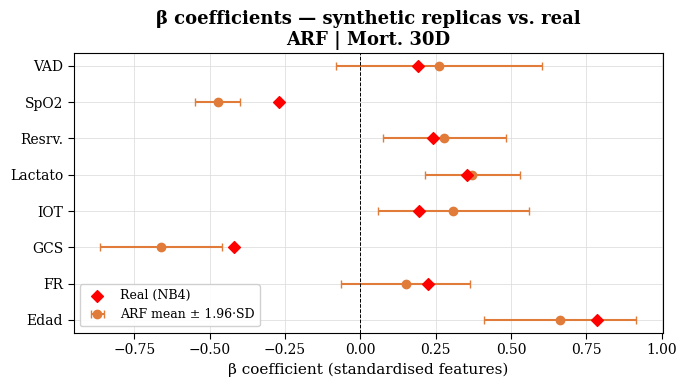

In [ ]:
# ── COEFFICIENT TABLE + CI OVERLAP ────────────────────────────────────────────
"""
PURPOSE: Extract β, OR, CI, p-value per feature per replica; compute CI overlap
         against the real-data model.

CI overlap (El Emam 2024): proportion of [lo_real, hi_real] covered by
[lo_synth, hi_synth].
    overlap = max(0, min(hi_r, hi_s) - max(lo_r, lo_s)) / (hi_r - lo_r)

NOTES:
- StandardScaler is applied before fitting to stabilise convergence.
- fit_regularized(alpha=0.1) is used as fallback when MLE fails due to
  quasi-complete separation (common with GCS concentrated at 15).
"""

def fit_logit_coef(df, features, outcome):
    """Fit statsmodels Logit; return coefficient summary DataFrame.

    Uses MLE first; falls back to L1-penalised fit if MLE diverges or
    produces infinite confidence intervals.
    """
    X = df[features + [outcome]].dropna()
    y = X[outcome].values
    Xm = sm.add_constant(
        StandardScaler().fit_transform(X[features]),
        has_constant='add')

    # Attempt MLE first
    try:
        res = sm.Logit(y, Xm).fit(method='bfgs', disp=False, maxiter=300)
        # Check for infinite CIs (sign of quasi-complete separation)
        ci_check = res.conf_int()
        if np.any(np.isinf(ci_check.values)):
            raise ValueError("Infinite CIs detected — switching to regularised fit.")
    except Exception:
        # Fallback: L1-penalised fit (resolves quasi-separation)
        res = sm.Logit(y, Xm).fit_regularized(
            method='l1', alpha=0.1, disp=False, maxiter=300)
        # fit_regularized does not provide conf_int / pvalues directly
        # → approximate using the Hessian at the solution
        try:
            # Compute standard errors from the Hessian
            bse = np.sqrt(np.diag(np.linalg.inv(-res.model.hessian(res.params))))
            ci_lo = res.params - 1.96 * bse
            ci_hi = res.params + 1.96 * bse
            pvals = 2 * stats.norm.sf(np.abs(res.params / (bse + 1e-12)))
        except Exception:
            bse   = np.full_like(res.params, np.nan)
            ci_lo = np.full_like(res.params, np.nan)
            ci_hi = np.full_like(res.params, np.nan)
            pvals = np.full_like(res.params, np.nan)

        coef = res.params[1:]
        return pd.DataFrame({
            'feature': features,
            'beta':    coef,
            'lo95':    ci_lo[1:],
            'hi95':    ci_hi[1:],
            'OR':      np.exp(coef),
            'pvalue':  pvals[1:],
        })

    coef = res.params[1:]
    ci   = res.conf_int().iloc[1:]
    pval = res.pvalues[1:]
    return pd.DataFrame({
        'feature': features,
        'beta':    coef.values,
        'lo95':    ci.iloc[:, 0].values,
        'hi95':    ci.iloc[:, 1].values,
        'OR':      np.exp(coef.values),
        'pvalue':  pval.values,
    })

def ci_overlap(lo_r, hi_r, lo_s, hi_s):
    """Proportion of real CI covered by synthetic CI."""
    if np.isnan(lo_r) or np.isnan(hi_r) or np.isnan(lo_s) or np.isnan(hi_s):
        return np.nan
    inter = max(0, min(hi_r, hi_s) - max(lo_r, lo_s))
    width = hi_r - lo_r
    return inter / width if width > 0 else np.nan

# Real model (training cohort — reference)
print("Fitting logistic regression on real training cohort...")
try:
    coef_real = fit_logit_coef(df_train, FEATURES, TARGET_COL)
    print("Real-data coefficients:")
    print(coef_real.to_string(index=False))
except Exception as e:
    print(f"⚠ Real-data logistic fit failed: {e}")
    print("  This may indicate quasi-complete separation in the training cohort.")
    # Create placeholder with NaN so downstream cells don't crash
    coef_real = pd.DataFrame({
        'feature': FEATURES,
        'beta':    [np.nan] * len(FEATURES),
        'lo95':    [np.nan] * len(FEATURES),
        'hi95':    [np.nan] * len(FEATURES),
        'OR':      [np.nan] * len(FEATURES),
        'pvalue':  [np.nan] * len(FEATURES),
    })

# Synthetic replicas
coef_records = []
for key, df_s in replicas.items():
    try:
        cr = fit_logit_coef(df_s, FEATURES, TARGET_COL)
        cr['replica'] = key
        coef_records.append(cr)
    except Exception as e:
        print(f"  {key}: fitting failed — {e}")

if coef_records:
    coef_all = pd.concat(coef_records, ignore_index=True)
else:
    print("⚠ No replicas fitted successfully.")
    coef_all = pd.DataFrame(columns=['feature', 'beta', 'lo95', 'hi95',
                                      'OR', 'pvalue', 'replica', 'ci_overlap'])

# CI overlap per feature per replica
if len(coef_all) > 0:
    real_ci = coef_real.set_index('feature')[['lo95', 'hi95']]
    coef_all['ci_overlap'] = coef_all.apply(
        lambda r: ci_overlap(real_ci.loc[r['feature'], 'lo95'],
                             real_ci.loc[r['feature'], 'hi95'],
                             r['lo95'], r['hi95']), axis=1)

    # Summary table
    summary = coef_all.groupby('feature').agg(
        beta_mean=('beta', 'mean'), beta_sd=('beta', 'std'),
        OR_mean=('OR', 'mean'),
        ci_overlap_mean=('ci_overlap', 'mean')
    ).reset_index()
    summary['beta_real'] = summary['feature'].map(
        coef_real.set_index('feature')['beta'])
    summary['OR_real'] = summary['feature'].map(
        coef_real.set_index('feature')['OR'])

    print(f"\nCoefficient summary ({GENERATOR}, {TARGET_COL}):")
    print(summary.to_string(index=False))

    coef_all.to_csv(os.path.join(OUTPUT_DIR, 'coef_table_replicas.csv'), index=False)
    summary.to_csv(os.path.join(OUTPUT_DIR, 'coef_summary.csv'), index=False)

    # Forest plot: mean β ± SD per feature, with real-data point
    fig, ax = plt.subplots(figsize=(7, 4))
    y_pos = np.arange(len(summary))
    ax.errorbar(summary['beta_mean'], y_pos,
                xerr=1.96 * summary['beta_sd'],
                fmt='o', color=TFG_COLORS[GENERATOR], capsize=3,
                label=f'{GENERATOR} mean ± 1.96·SD')
    ax.scatter(summary['beta_real'], y_pos, marker='D',
               color='red', zorder=5, label='Real (NB4)')
    ax.axvline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(summary['feature'])
    ax.set_xlabel('β coefficient (standardised features)')
    ax.set_title(f'β coefficients — synthetic replicas vs. real\n{GENERATOR} | {TARGET_COL}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'coef_forest_plot.png'), dpi=150)
    plt.show()
else:
    print("⚠ Skipping coefficient plots — no fitted replicas.")

## **6. El Emam Replicability Framework**

Following El Emam et al. (2024), replicability is evaluated using
$m =$ `N_REPLICAS` synthetic datasets combined via **Rubin's combining rules
adapted for fully synthetic data** (Raghunathan et al. 2003).

The analytical workload is **logistic regression**

### Combining rules (El Emam et al. 2024 / Raghunathan et al. 2003)

Given $m$ fitted logistic regression models with parameter estimates $\hat{q}_i$
and within-model variances $v_i$ (derived from standard errors):

$$\bar{q}_m = \frac{1}{m} \sum_{i=1}^{m} \hat{q}_i$$

$$\bar{v} = \frac{1}{m} \sum_{i=1}^{m} v_i$$

$$T_f = \bar{v} \cdot \left(\frac{k}{n} + \frac{1}{m}\right)$$

where $k$ is the mean synthetic dataset size and $n$ is the real training set
size.  The $k/n$ term inflates variance to account for the size ratio between
synthetic and real data — a key difference from the standard missing-data
combining rules.

The 95 % combined CI is $\bar{q}_m \pm 1.96\sqrt{T_f}$.

### Eight replicability metrics evaluated

**Criterion A — Agreement with real-data results:**

| Metric | Definition | Pass condition |
|--------|-----------|----------------|
| A1 Decision agreement | Same direction *and* significance as real | Synth sig. ↔ real sig., same sign |
| A2 Estimate agreement | Synthetic combined estimate within real 95 % CI | $lo_{\text{real}} \le \bar{q}_m \le hi_{\text{real}}$ |
| A3 Standardised difference | Pooled Z-statistic | $|Z| < 1.96$ |
| A4 CI overlap | Proportion of real CI covered | Maximise towards 1.0 |

**Criterion B — Validity of population inferences:**

| Metric | Definition |
|--------|-----------|
| B1 Bias | $\bar{q}_m - q_{\text{real}}$ — systematic over/under-estimation |
| B2 CI coverage | Combined synthetic CI contains the real estimate (adapted from Bias-eliminated coverage) |
| B3 Statistical power | Proportion of replicas with significant result (target ≥ 0.80) |
| B4 Empirical SE | Standard deviation of $\hat{q}_i$ across replicas |

Results are presented as a Boolean heatmap (pass/fail) for Criterion A and
continuous values for Criterion B.  Both are saved to `elemam_replicability.csv`.

> **Adaptation note:** El Emam et al. (2024) define *Bias-eliminated coverage*
> as the proportion of 95 % CIs (across 1000 Monte Carlo iterations) that
> contain the **averaged** parameter estimate.  Since this TFG has a single
> real dataset (not a simulation study), B2 is adapted: it checks whether the
> **real-data estimate** falls within the combined synthetic CI.  This is the
> natural single-study analogue of the original metric.



El Emam Replicability Framework — ARF | Mort. 30D
feature  decision_agree  estimate_agree  std_diff_ok  ci_overlap      bias  ci_coverage  power  empirical_SE
   Edad            True            True         True    0.751599 -0.124990         True    1.0      0.122480
    GCS            True           False        False    0.272872 -0.240830        False    1.0      0.097335
Lactato            True            True         True    1.000000  0.018448         True    1.0      0.075993
   SpO2            True           False        False    0.373090 -0.203181        False    1.0      0.036457
 Resrv.            True            True         True    0.897124  0.037443         True    0.9      0.098559
    IOT            True            True         True    0.596070  0.114728         True    0.9      0.121623
    VAD           False            True         True    1.000000  0.068163         True    0.0      0.165502
     FR           False            True         True    0.821301 -0.073652   

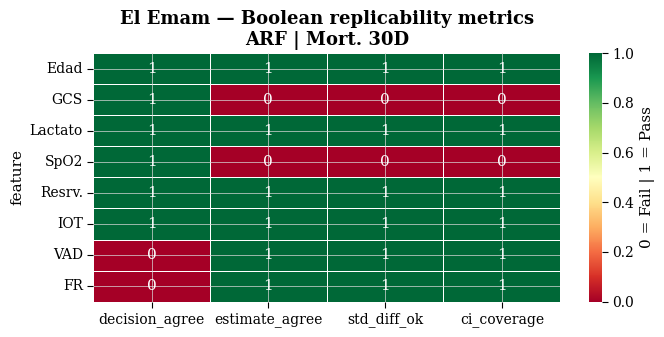

In [ ]:
# ── EL EMAM REPLICABILITY FRAMEWORK ──────────────────────────────────────────
"""
PURPOSE: Evaluate 8 replicability metrics using m replicas + Rubin combining rules.

REFERENCE: El Emam et al. (2024) Scientific Reports 14:6978.

The 'true' reference parameter is taken from the real training cohort logistic
regression (coef_real).  This is equivalent to treating the real-data estimate
as the population value — appropriate given no separate population data exists.
"""

def rubin_combine(betas, variances, n_real, n_synth):
    """
    Apply Rubin combining rules for fully synthetic data.

    Parameters
    ----------
    betas : array-like
        Parameter estimates from m synthetic datasets.
    variances : array-like
        Variance of each estimate (derived from SE²).
    n_real : int
        Size of the real training dataset.
    n_synth : int
        Mean size of the synthetic datasets.

    Returns
    -------
    tuple: (q_bar, tf, lo95, hi95)
    """
    m     = len(betas)
    q_bar = np.mean(betas)
    v_bar = np.mean(variances)
    tf    = v_bar * (n_synth / n_real + 1 / m)
    se    = np.sqrt(max(tf, 1e-12))
    lo    = q_bar - 1.96 * se
    hi    = q_bar + 1.96 * se
    return q_bar, tf, lo, hi

n_real  = len(df_train)
n_synth = int(np.mean([len(r) for r in replica_list]))

# Reference: real-data estimates (treated as population values)
ref_beta = coef_real.set_index('feature')['beta']
ref_lo   = coef_real.set_index('feature')['lo95']
ref_hi   = coef_real.set_index('feature')['hi95']
ref_sig  = coef_real.set_index('feature')['pvalue'] < 0.05

replicability = []
for feat in FEATURES:
    betas_f = coef_all[coef_all['feature'] == feat]['beta'].values
    # Derive variance from CI width: SE = (hi - lo) / (2 * 1.96) → var = SE²
    vars_f  = ((coef_all[coef_all['feature'] == feat]['hi95'].values -
                coef_all[coef_all['feature'] == feat]['lo95'].values) / (2 * 1.96)) ** 2

    q_bar, tf, lo_c, hi_c = rubin_combine(betas_f, vars_f, n_real, n_synth)
    se_c = np.sqrt(tf)

    b_real  = ref_beta[feat]
    lo_real = ref_lo[feat]
    hi_real = ref_hi[feat]

    # ── Metric A1 — Decision agreement ───────────────────────────────────────
    synth_sig = (lo_c > 0) | (hi_c < 0)
    real_sig  = ref_sig[feat]
    synth_dir = np.sign(q_bar)
    real_dir  = np.sign(b_real)
    decision_agree = bool((synth_sig == real_sig) and (synth_dir == real_dir))

    # ── Metric A2 — Estimate agreement ───────────────────────────────────────
    estimate_agree = bool(lo_real <= q_bar <= hi_real)

    # ── Metric A3 — Standardised difference ──────────────────────────────────
    real_se    = (hi_real - lo_real) / (2 * 1.96)
    pooled_se  = np.sqrt((se_c**2 + real_se**2) / 2)
    z_val      = abs(q_bar - b_real) / (pooled_se + 1e-12)
    std_diff   = bool(z_val < 1.96)

    # ── Metric A4 — CI overlap ───────────────────────────────────────────────
    inter      = max(0, min(hi_real, hi_c) - max(lo_real, lo_c))
    ci_ov      = inter / (hi_real - lo_real) if (hi_real - lo_real) > 0 else np.nan

    # ── Metric B1 — Bias ─────────────────────────────────────────────────────
    bias_val = q_bar - b_real

    # ── Metric B2 — CI coverage ──────────────────────────────────────────────
    coverage = bool(lo_c <= b_real <= hi_c)

    # ── Metric B3 — Power ────────────────────────────────────────────────────
    sig_count = sum((coef_all[coef_all['feature'] == feat]['lo95'].values > 0) |
                    (coef_all[coef_all['feature'] == feat]['hi95'].values < 0))
    power_val = sig_count / N_REPLICAS

    # ── Metric B4 — Empirical SE ─────────────────────────────────────────────
    emp_se = np.std(betas_f)

    replicability.append({
        'feature':          feat,
        'q_combined':       q_bar,
        'q_real':           b_real,
        'lo_combined':      lo_c,
        'hi_combined':      hi_c,
        'decision_agree':   decision_agree,
        'estimate_agree':   estimate_agree,
        'std_diff_ok':      std_diff,
        'ci_overlap':       ci_ov,
        'bias':             bias_val,
        'ci_coverage':      coverage,
        'power':            power_val,
        'empirical_SE':     emp_se,
    })

rep_df = pd.DataFrame(replicability)
print(f"\nEl Emam Replicability Framework — {GENERATOR} | {TARGET_COL}")
print(rep_df[[
    'feature', 'decision_agree', 'estimate_agree', 'std_diff_ok',
    'ci_overlap', 'bias', 'ci_coverage', 'power', 'empirical_SE'
]].to_string(index=False))
rep_df.to_csv(os.path.join(OUTPUT_DIR, 'elemam_replicability.csv'), index=False)

# Summary heatmap (Boolean metrics as 0/1)
bool_cols = ['decision_agree', 'estimate_agree', 'std_diff_ok', 'ci_coverage']
heat_data  = rep_df.set_index('feature')[bool_cols].astype(int)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(heat_data, annot=True, fmt='d', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.4, ax=ax,
            cbar_kws={'label': '0 = Fail | 1 = Pass'})
ax.set_title(f'El Emam — Boolean replicability metrics\n{GENERATOR} | {TARGET_COL}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'elemam_heatmap_boolean.png'), dpi=150)
plt.show()

## **7. Correlation Distances and Variable Importance (VIMP)**

### Correlation distance (Spearman)

Pairwise **Spearman** correlation matrices are computed for the real training
set and each synthetic replica.  The squared difference matrix

$$\Delta_{jk} = (\rho^{\text{real}}_{jk} - \rho^{\text{synth}}_{jk})^2$$

quantifies how well the synthetic data preserves the dependency structure.

The **feature–target correlations** (last row/column of $\Delta$) are the most
clinically critical: as shown by Miletic & Sariyar (2025) [N3B], downstream
model utility is primarily driven by the fidelity of predictor–outcome
correlations, not feature–feature correlations.

### Variable Importance (VIMP)

A Random Forest classifier is trained on each synthetic replica (same
hyperparameters as the pMSE classifier, Section 2).  Two importance metrics are
extracted per feature:

| Metric | Definition | Sensitivity |
|--------|-----------|-------------|
| **Gini importance** | Mean decrease in impurity across all trees | Biased towards high-cardinality features |
| **Permutation importance** | Drop in accuracy when feature values are shuffled on the test set | Unbiased; can be negative if feature adds noise |

The importance ranking is compared to the real-data ranking.  A generator that
inverts the variable importance order will produce models that assign risk
weights inconsistently with the clinical signal.

### Inputs / Outputs

- **Input:** synthetic replicas + real training set; real test set for
  permutation importance.
- **Output:** heatmap of mean Gini importances across replicas; bar chart of
  permutation importances (mean ± SD); saved to `vimp_results.csv`.


  ds01: feature-target dist=0.0011 | feature-feature dist=0.0060
  ds02: feature-target dist=0.0018 | feature-feature dist=0.0057
  ds03: feature-target dist=0.0021 | feature-feature dist=0.0046
  ds04: feature-target dist=0.0017 | feature-feature dist=0.0052
  ds05: feature-target dist=0.0024 | feature-feature dist=0.0083
  ds06: feature-target dist=0.0022 | feature-feature dist=0.0063
  ds07: feature-target dist=0.0028 | feature-feature dist=0.0051
  ds08: feature-target dist=0.0008 | feature-feature dist=0.0054
  ds09: feature-target dist=0.0009 | feature-feature dist=0.0055
  ds10: feature-target dist=0.0009 | feature-feature dist=0.0062


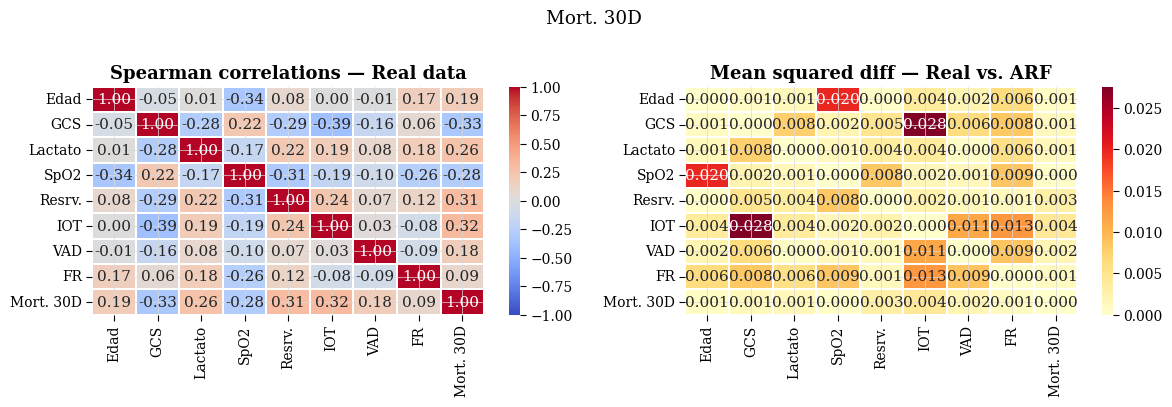

Permutation importance scoring: roc_auc

VIMP comparison — ARF | Mort. 30D:
feature  gini_real  gini_synth  perm_real  perm_synth
   Edad   0.209409    0.148632   0.071885    0.034924
    GCS   0.132136    0.210340   0.057485    0.069983
Lactato   0.236968    0.173324   0.071589    0.017290
   SpO2   0.209077    0.228392   0.028453    0.031170
 Resrv.   0.042467    0.062898   0.006689    0.010312
    IOT   0.024834    0.045214   0.002297    0.010788
    VAD   0.002466    0.001292   0.001615    0.000705
     FR   0.142642    0.129909   0.025488    0.013775


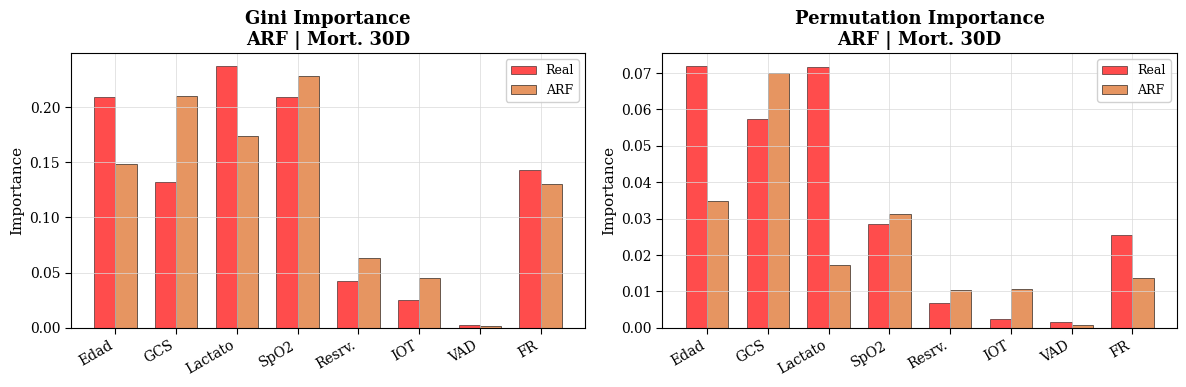

In [ ]:
# ── CORRELATION DISTANCES + VIMP ──────────────────────────────────────────────
"""
PURPOSE:
  (a) Compute squared Spearman correlation matrix differences (real vs. synthetic).
  (b) Compute Gini + permutation importance (real vs. synthetic replicas).

REFERENCE: Miletic & Sariyar 2025 [N3B], Section "Correlation Distance and Utility".
"""

# ── (a) Correlation distances ─────────────────────────────────────────────────
cols_corr = FEATURES + [TARGET_COL]

def spearman_matrix(df, cols):
    """Compute Spearman rank-correlation matrix with median imputation.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    cols : list of str
        Columns to include in the correlation matrix.

    Returns
    -------
    pd.DataFrame
        Square Spearman correlation matrix.
    """
    return df[cols].fillna(df[cols].median()).corr(method='spearman')

corr_real   = spearman_matrix(df_train, cols_corr)
corr_diffs  = []

for key, df_s in replicas.items():
    corr_s  = spearman_matrix(df_s, cols_corr)
    diff_sq = (corr_real - corr_s) ** 2
    corr_diffs.append(diff_sq)
    ft_dist = diff_sq[TARGET_COL].drop(TARGET_COL).mean()
    ff_dist = diff_sq.drop(columns=TARGET_COL).drop(TARGET_COL).values[
        np.triu_indices(len(FEATURES), k=1)].mean()
    print(f"  {key}: feature-target dist={ft_dist:.4f} | "
          f"feature-feature dist={ff_dist:.4f}")

mean_diff = np.mean([d.values for d in corr_diffs], axis=0)
mean_diff_df = pd.DataFrame(mean_diff, index=cols_corr, columns=cols_corr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(corr_real, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.3)
axes[0].set_title('Spearman correlations — Real data')
sns.heatmap(mean_diff_df, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, ax=axes[1], linewidths=0.3)
axes[1].set_title(f'Mean squared diff — Real vs. {GENERATOR}')
plt.suptitle(f'{TARGET_COL}', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_distance.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── (b) VIMP ──────────────────────────────────────────────────────────────────
imp   = SimpleImputer(strategy='median')
X_r   = imp.fit_transform(df_train[FEATURES])
y_r   = df_train[TARGET_COL].values
X_te  = imp.transform(df_test[FEATURES])
y_te  = df_test[TARGET_COL].values

# Use a threshold-independent metric for permutation importance.
# Average precision is preferred for the rarest endpoint; ROC-AUC otherwise.
VIMP_SCORING = 'average_precision' if TARGET_COL == 'Mort. 2D' else 'roc_auc'
print(f"Permutation importance scoring: {VIMP_SCORING}")

# Real-data VIMP
rf_real = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
rf_real.fit(X_r, y_r)
gini_real  = rf_real.feature_importances_
perm_real  = permutation_importance(rf_real, X_te, y_te,
                                    n_repeats=20, random_state=42,
                                    scoring=VIMP_SCORING).importances_mean

gini_synth_all = []
perm_synth_all = []
for df_s in replica_list:
    X_s = imp.transform(df_s[FEATURES])
    y_s = df_s[TARGET_COL].values
    rf_s = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
    rf_s.fit(X_s, y_s)
    gini_synth_all.append(rf_s.feature_importances_)
    pi = permutation_importance(rf_s, X_te, y_te,
                                n_repeats=20, random_state=42,
                                scoring=VIMP_SCORING).importances_mean
    perm_synth_all.append(pi)

gini_mean = np.mean(gini_synth_all, axis=0)
perm_mean = np.mean(perm_synth_all, axis=0)

vimp_df = pd.DataFrame({
    'feature':     FEATURES,
    'gini_real':   gini_real,
    'gini_synth':  gini_mean,
    'perm_real':   perm_real,
    'perm_synth':  perm_mean,
})
print(f"\nVIMP comparison — {GENERATOR} | {TARGET_COL}:")
print(vimp_df.to_string(index=False))
vimp_df.to_csv(os.path.join(OUTPUT_DIR, 'vimp_comparison.csv'), index=False)

# VIMP plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(
        axes,
        [('gini_real', 'gini_synth'), ('perm_real', 'perm_synth')],
        ['Gini Importance', 'Permutation Importance']):
    x = np.arange(len(FEATURES))
    w = 0.35
    ax.bar(x - w/2, vimp_df[metric[0]], w, label='Real',
           color='red', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.bar(x + w/2, vimp_df[metric[1]], w, label=GENERATOR,
           color=TFG_COLORS[GENERATOR], alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURES, rotation=30, ha='right')
    ax.set_ylabel('Importance')
    ax.set_title(f'{title}\n{GENERATOR} | {TARGET_COL}')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vimp_comparison.png'), dpi=150)
plt.show()

## **8. Train On Syntetic and Test on Real (TSTR)**

The NB4 risk-scoring pipeline is evaluated under a strict
**Train-on-Synthetic, Test-on-Real (TSTR)** paradigm.

Two related endpoints are reported:

1. **Ridge probability model:** the underlying L2-regularised logistic
   regression trained on each synthetic replica and evaluated on the real test
   set.
2. **β-rounded integer risk score:**the final clinical artefact from **NB4**:
   coefficients are converted into integer points, total score is computed, and score-to-probability calibration is learned on the synthetic training data.

The **primary TSTR endpoint is the β-rounded integer score**, because this is
the final risk scale developed in **NB4**. The Ridge model is reported as supporting
evidence.

### Leakage guard

The real test set is used only for final evaluation. The following elements are learned before touching the test outcomes:

- model coefficients
- β-rounded point table
- score-to-probability calibration
- Youden threshold for classification metrics

For TSTR these are learned from synthetic training data. For TRTR they are
learned from the real training cohort. No threshold or calibration model is
fitted using the real test labels.


Reference categories (Mort. 30D):
  Edad_cat          : reference = "(-inf, 58]"
  GCS_cat           : reference = "15"
  Lactato_cat       : reference = "(-inf, 3.5]"
  SpO2_cat          : reference = "[94, +inf)"
  Resrv._cat        : reference = "0"
  IOT_cat           : reference = "0"
  VAD_cat           : reference = "0"
  FR_cat            : reference = "(14, 22]"

Category order (first = reference dropped by OHE):
  Edad_cat          : (-inf, 58] (ref) | 3 non-ref levels
  GCS_cat           : 15 (ref) | 12 non-ref levels
  Lactato_cat       : (-inf, 3.5] (ref) | 2 non-ref levels
  SpO2_cat          : [94, +inf) (ref) | 2 non-ref levels
  Resrv._cat        : 0 (ref) | 1 non-ref levels
  IOT_cat           : 0 (ref) | 1 non-ref levels
  VAD_cat           : 0 (ref) | 1 non-ref levels
  FR_cat            : (14, 22] (ref) | 3 non-ref levels

Loading TRTR integer score from NB4 score_config...
  TRTR score map loaded — max theoretical score: 10 pts
  Fitting TRTR Ridge pipeline (suppo

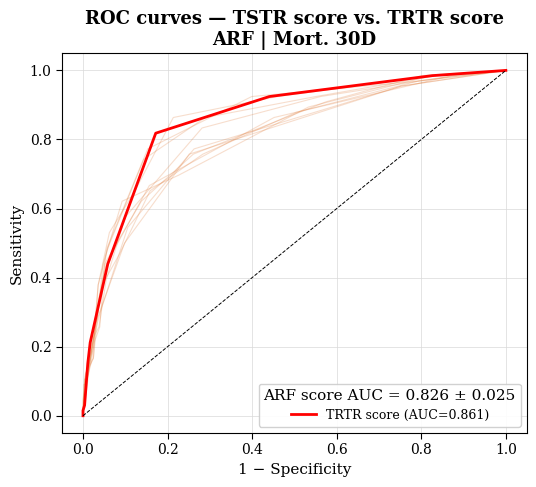

In [ ]:
# ── TSTR — RISK SCORING SYSTEM ────────────────────────────────────────────────
"""
PURPOSE : Train the NB4 risk scoring pipeline on each synthetic replica and
          evaluate discrimination and calibration on the real test set (TSTR).

DESIGN PRINCIPLES — mirror NB4 exactly:
  1. Binning       : fixed clinical cutpoints (CLINICAL_CUTS); GCS as ordered
                     categories (3–15); binary variables as {0,1}.  Never
                     re-estimated on synthetic data.
  2. Reference     : selected on REAL training data by lowest mortality rate
                     (data-driven), overridden only for GCS_cat='15' (clinical
                     convention).  The same reference order is imposed on all
                     synthetic datasets via the shared `categories` list.
  3. String coerce : mirrors NB4 Section 10a — reads existing reference-first order,
                     appends __MISSING__ if needed.  No per-variable reordering
                     happens here; that was done in step 2.
  4. OHE           : drop='first' drops the reference (first category) for each
                     variable, consistent with NB4 Section 10b.
  5. Ridge LR      : same C_GRID, same scoring (neg_brier_score), same 10-fold
                     stratified GridSearchCV as NB4 Section 10b.
  6. β extraction  : mirrors NB4 Section 10c — reference-first category order determines
                     which level gets β=0; all others get their Ridge β.
  7. CLIP_NEGATIVE : mirrors NB4 Section 10c flag (set in Cell 2).

SOURCE OF COEFFICIENTS (TSTR):
  fit_scoring_pipeline is called with SYNTHETIC data as training set.
  Coefficients come from the Ridge LR refitted on all synthetic training rows
  with the CV-selected C — never from real training data.
  Evaluation always uses the real test set.
"""

MISSING_TOKEN = '__MISSING__'
MIN_N_REF     = 30   # minimum category size to be eligible as reference


# ════════════════════════════════════════════════════════════════════════════
# Step 1 — Binning helpers  (mirror NB4 Section 9)
# ════════════════════════════════════════════════════════════════════════════

def cut_bins(series, cutpoints, right=True, precision=3):
    """Bin a numeric series using specified cut-points (mirrors NB4 Section 9)."""
    s = pd.to_numeric(series, errors='coerce')
    cuts_list = [-np.inf] + list(cutpoints) + [np.inf]
    labels = []
    for j in range(len(cuts_list) - 1):
        a, b = cuts_list[j], cuts_list[j + 1]
        la = f'{a:.{precision}g}' if np.isfinite(a) else '-inf'
        lb = f'{b:.{precision}g}' if np.isfinite(b) else '+inf'
        labels.append(f'({la}, {lb}]' if right else f'[{la}, {lb})')
    return pd.cut(s, bins=cuts_list, labels=labels,
                  include_lowest=True, right=right).astype('category')


def make_gcs_cat(gcs, levels=None):
    """Keep the full Glasgow Coma Scale score as ordered categories (3–15)."""
    if levels is None:
        levels = list(range(3, 16))
    g = pd.to_numeric(gcs, errors='coerce').round()
    g = g.where(g.isin(set(levels)))
    categories = [str(x) for x in levels]
    out = g.astype('Int64').astype('string')
    return pd.Categorical(out, categories=categories, ordered=True)


def make_binary_cat(series):
    """Robust binary encoder (mirrors NB4 Section 9)."""
    s = pd.to_numeric(series, errors='coerce')
    if set(s.dropna().unique()).issubset({0, 1}):
        out = s.map({0: '0', 1: '1'})
    elif set(s.dropna().unique()).issubset({1, 2}):
        out = s.map({2: '0', 1: '1'})
    else:
        vc = s.value_counts(dropna=True)
        if len(vc) >= 2:
            no_val = vc.idxmax()
            yes_val = [v for v in vc.index if v != no_val][0]
            out = s.map({no_val: '0', yes_val: '1'})
        else:
            out = pd.Series(pd.NA, index=s.index, dtype='object')
    return pd.Categorical(out, categories=['0', '1'], ordered=True)


def prepare_scoring_df(df_in):
    """Apply NB4-style binning to a DataFrame.

    Returns (df_cat, score_cat_cols) where df_cat contains only _cat columns
    with the same category labels as NB4 Section 9.  Category ORDER is not set here
    — reference-first ordering is applied separately in Step 2.
    """
    df_out   = pd.DataFrame(index=df_in.index)
    cat_cols = []
    for var in FEATURES:
        col_name = f'{var}_cat'
        if var in GCS_VARS:
            df_out[col_name] = make_gcs_cat(df_in[var], GCS_LEVELS)
        elif var in BINARY_VARS:
            df_out[col_name] = make_binary_cat(df_in[var])
        elif var in CLINICAL_CUTS:
            df_out[col_name] = cut_bins(
                df_in[var],
                CLINICAL_CUTS[var],
                right=(var not in RIGHT_FALSE_VARS)
            )
        else:
            df_out[col_name] = make_binary_cat(df_in[var])   # fallback
        cat_cols.append(col_name)
    return df_out, cat_cols


# ════════════════════════════════════════════════════════════════════════════
# Step 2 — Reference category selection on REAL training data
#           (mirrors NB4 Section 9 choose_reference + reorder_ref_first)
# ════════════════════════════════════════════════════════════════════════════

# Fixed override: GCS clinical convention (15 = normal neurological status)
REFERENCE_CATEGORY_OVERRIDES = {'GCS_cat': '15'}


def _risk_table(df_cat, col, y):
    """Mortality rate per category level (training data only)."""
    tmp = pd.DataFrame({'cat': df_cat[col], 'y': y})
    tmp = tmp.dropna()
    return tmp.groupby('cat', observed=True)['y'].agg(['sum', 'count', 'mean'])


def _choose_reference(tab, min_n=MIN_N_REF):
    """Select level with lowest mortality rate among levels with n >= min_n."""
    eligible = tab[tab['count'] >= min_n]
    if eligible.empty:
        eligible = tab
    return eligible.sort_values(['mean', 'count'], ascending=[True, False]).index[0]


def _reorder_ref_first(cat_series, ref):
    """Place reference category first; return reordered categorical series."""
    cats = list(cat_series.cat.categories)
    if ref in cats:
        cats.remove(ref)
        cats.insert(0, ref)
        return cat_series.cat.reorder_categories(cats, ordered=True)
    return cat_series


# Bin real training data and select references
X_train_raw, score_cat_cols = prepare_scoring_df(df_train)
X_test_raw,  _              = prepare_scoring_df(df_test)
y_train_real = pd.to_numeric(df_train[TARGET_COL], errors='coerce').dropna().astype(int)
y_test       = pd.to_numeric(df_test[TARGET_COL],  errors='coerce').dropna().astype(int)

# Align indices after dropna
X_train_raw = X_train_raw.loc[y_train_real.index]
X_test_raw  = X_test_raw.loc[y_test.index]

ref_levels = {}   # {col: reference_category_str}  — used in β extraction (Step 6)
print(f'Reference categories ({TARGET_COL}):')
for col in score_cat_cols:
    override = REFERENCE_CATEGORY_OVERRIDES.get(col)
    if override is not None:
        ref = override
    else:
        tab = _risk_table(X_train_raw, col, y_train_real)
        ref = str(_choose_reference(tab))
    ref_levels[col] = ref
    # Apply reference-first ordering to both real splits
    X_train_raw[col] = _reorder_ref_first(X_train_raw[col], ref)
    X_test_raw[col]  = _reorder_ref_first(X_test_raw[col],  ref)
    print(f'  {col:<18}: reference = "{ref}"')


# ════════════════════════════════════════════════════════════════════════════
# Step 3 — String coercion  (mirrors NB4 Section 10a force_string_categories)
# ════════════════════════════════════════════════════════════════════════════

def force_string_categories(df_in, cat_cols, missing_token=MISSING_TOKEN):
    """Cast categorical columns to string preserving reference-first order.

    Mirrors NB4 Section 10a exactly.  Reference-first ordering was already applied
    in Step 2; this function only casts to str and appends __MISSING__ if
    needed.  It does NOT reorder categories.
    """
    df2 = df_in.copy()
    for col in cat_cols:
        if not isinstance(df2[col].dtype, pd.CategoricalDtype):
            df2[col] = df2[col].astype('category')
        cats_str = [str(x) for x in df2[col].cat.categories]
        df2[col] = df2[col].apply(lambda v: missing_token if pd.isna(v) else str(v))
        if (df2[col] == missing_token).any() and missing_token not in cats_str:
            cats_str = cats_str + [missing_token]
        df2[col] = pd.Categorical(df2[col], categories=cats_str, ordered=True)
    return df2


X_train_s = force_string_categories(X_train_raw, score_cat_cols)
X_test_s  = force_string_categories(X_test_raw,  score_cat_cols)

# categories list: reference is first in each sublist → OHE drop='first' drops it
categories = [list(X_train_s[col].cat.categories) for col in score_cat_cols]

print('\nCategory order (first = reference dropped by OHE):')
for col, cats in zip(score_cat_cols, categories):
    print(f'  {col:<18}: {cats[0]} (ref) | {len(cats)-1} non-ref levels')


# ════════════════════════════════════════════════════════════════════════════
# Step 4+5 — OHE + Ridge LR pipeline  (mirrors NB4 Section 10b)
# ════════════════════════════════════════════════════════════════════════════

def make_ohe(cats):
    """Create OneHotEncoder compatible across sklearn versions."""
    try:
        return OneHotEncoder(categories=cats, drop='first',
                             handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(categories=cats, drop='first',
                             handle_unknown='ignore', sparse=False)


def fit_scoring_pipeline(X_cat, y, categories_list, cat_cols):
    """Fit NB4-style scoring pipeline: OHE → Ridge LR with 10-fold CV.

    Parameters
    ----------
    X_cat          : DataFrame with stringified categorical columns (ref first).
    y              : binary outcome array.
    categories_list: list of lists — category order per column (from real training).
                     Passed to OHE so all pipelines share the same column structure.
    cat_cols       : ordered list of categorical column names.

    Returns
    -------
    Fitted sklearn Pipeline (best_estimator_ from GridSearchCV).
    """
    preprocessor = ColumnTransformer(
        transformers=[('cat', make_ohe(categories_list), cat_cols)],
        remainder='drop')

    prevalence = float(np.asarray(y).mean())
    cw_grid    = ['balanced', None] if prevalence < 0.08 else [None]
    C_GRID     = [0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

    logit     = LogisticRegression(penalty='l2', solver='lbfgs',
                                   max_iter=5000, random_state=42)
    pipe_base = Pipeline([('pre', preprocessor), ('model', logit)])

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    gs = GridSearchCV(
        estimator=pipe_base,
        param_grid={'model__C': C_GRID, 'model__class_weight': cw_grid},
        scoring='neg_brier_score',
        cv=cv, n_jobs=-1, refit=True,
    )
    gs.fit(X_cat, y)
    return gs.best_estimator_


# ════════════════════════════════════════════════════════════════════════════
# Step 6 — β extraction helpers  (mirrors NB4 Section 10c)
# ════════════════════════════════════════════════════════════════════════════

def _parse_ohe_feature(feat, cols):
    """Recover (variable_col, level_str) from an OHE feature name."""
    if '__' in feat:
        feat = feat.split('__', 1)[-1]
    for col in sorted(cols, key=len, reverse=True):
        if feat.startswith(col + '_'):
            return col, feat[len(col) + 1:]
    return None, feat


def _round_beta(b, threshold=0.45):
    """Round β to integer using modified threshold (Zhang et al. 2017)."""
    sign = 1 if b >= 0 else -1
    return sign * int(np.floor(abs(b) + (1 - threshold)))


def extract_score_map(pipe, cat_cols, ref_lvls,
                      round_thr=0.45, clip_negative=False):
    """Extract β coefficients and apply β-rounding (mirrors NB4 Section 10c).

    Parameters
    ----------
    pipe          : fitted sklearn Pipeline (OHE → Ridge LR).
    cat_cols      : list of categorical column names.
    ref_lvls      : dict {col: reference_str} — reference gets β=0.
                    Must be derived from REAL training data (Step 2).
    round_thr     : β-rounding threshold (Zhang et al. 2017, default 0.45).
    clip_negative : if True, clip negative points to 0 (mirrors NB4 CLIP_NEGATIVE).
                    Must match NB4 Section 10c for a valid TSTR comparison.

    Returns
    -------
    score_map : dict {(col, level): int_points}
    max_score : int — theoretical maximum score
    points_df : DataFrame — full β and points table
    """
    ohe        = pipe.named_steps['pre'].named_transformers_['cat']
    feat_names = ohe.get_feature_names_out(cat_cols)
    betas      = pipe.named_steps['model'].coef_.ravel()

    coef_df = pd.DataFrame({'feature': feat_names, 'beta': betas})
    coef_df[['variable', 'level']] = coef_df['feature'].apply(
        lambda s: pd.Series(_parse_ohe_feature(s, cat_cols)))

    # Re-insert reference levels (β = 0, dropped by OHE drop='first')
    rows = []
    for var in cat_cols:
        rows.append({'variable': var, 'level': ref_lvls[var],
                     'beta': 0.0, 'is_reference': True})
        sub = coef_df[coef_df['variable'] == var][['level', 'beta']]
        for r in sub.itertuples(index=False):
            rows.append({'variable': var, 'level': r.level,
                         'beta': float(r.beta), 'is_reference': False})

    points_df = pd.DataFrame(rows)
    points_df['points'] = (points_df['beta']
                           .apply(lambda b: _round_beta(b, round_thr))
                           .astype(int))

    # Mirror NB4 Section 10c CLIP_NEGATIVE
    if clip_negative:
        mask_nonref = ~points_df['is_reference']
        points_df.loc[mask_nonref, 'points'] = (
            points_df.loc[mask_nonref, 'points'].clip(lower=0))

    score_map = {(row['variable'], row['level']): int(row['points'])
                 for _, row in points_df.iterrows()}
    max_score = int(sum(points_df.groupby('variable')['points'].max()))
    return score_map, max_score, points_df


# ════════════════════════════════════════════════════════════════════════════
# Utility helpers
# ════════════════════════════════════════════════════════════════════════════

def _compute_risk_score(df_in, score_map, cat_cols, missing_token=MISSING_TOKEN):
    """Compute total integer risk score per patient (mirrors NB4 Section 10d)."""
    scores = np.zeros(len(df_in), dtype=int)
    for col in cat_cols:
        col_pts = df_in[col].apply(
            lambda v: score_map.get(
                (col, missing_token if pd.isna(v) else str(v)), 0)
        ).astype(int).values
        scores += col_pts
    return pd.Series(scores, index=df_in.index, name='risk_score')


def youden_threshold_from_train(y_train, scores_train):
    """Return Youden-optimal threshold learned on a training partition only."""
    fpr, tpr, thresholds = roc_curve(y_train, scores_train)
    j = tpr - fpr
    idx = int(np.nanargmax(j))
    return float(thresholds[idx]), float(j[idx])


def binary_metrics_at_threshold(y_true, scores, threshold):
    """Sensitivity, specificity, PPV, NPV and test J at a fixed threshold."""
    y_pred = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    ppv  = tp / (tp + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)
    return y_pred, sens, spec, ppv, npv, sens + spec - 1


def fit_score_glm_predict(y_train, scores_train, scores_test):
    """Fit outcome ~ integer score on training data and predict test probabilities."""
    X_train_glm = sm.add_constant(np.asarray(scores_train, dtype=float),
                                  has_constant='add')
    X_test_glm  = sm.add_constant(np.asarray(scores_test, dtype=float),
                                  has_constant='add')
    try:
        glm = sm.GLM(np.asarray(y_train).astype(int), X_train_glm,
                     family=sm.families.Binomial()).fit()
    except Exception:
        # Rare fallback for separation in very sparse endpoints.
        glm = sm.GLM(np.asarray(y_train).astype(int), X_train_glm,
                     family=sm.families.Binomial()).fit_regularized(
                         alpha=1e-4, L1_wt=0.0)
    p_test_score = np.asarray(glm.predict(X_test_glm))
    return np.clip(p_test_score, 0, 1), glm


def hosmer_lemeshow(y_true, y_pred, n_bins=10):
    """Hosmer-Lemeshow goodness-of-fit test."""
    df_hl = pd.DataFrame({'y': y_true, 'p': y_pred})
    df_hl['decile'] = pd.qcut(df_hl['p'], n_bins, duplicates='drop', labels=False)
    obs  = df_hl.groupby('decile')['y'].sum()
    exp  = df_hl.groupby('decile')['p'].sum()
    n    = df_hl.groupby('decile')['y'].count()
    chi2_stat = (((obs - exp) ** 2) / (exp * (1 - exp / n) + 1e-12)).sum()
    dof  = len(obs) - 2
    return chi2_stat, chi2.sf(chi2_stat, max(dof, 1))


# ════════════════════════════════════════════════════════════════════════════
# TRTR baseline  (train on real, test on real)
#
# INTEGER SCORE: loaded from NB4 score_config JSON to guarantee bit-for-bit
# reproducibility of the β-rounding table regardless of CV stochasticity.
# RIDGE PROBS:   still fitted here (supporting endpoint only).
# ════════════════════════════════════════════════════════════════════════════
print('\nLoading TRTR integer score from NB4 score_config...')

# ── Load NB4 score_config JSON ───────────────────────────────────────────────
_nb4_output_dir = os.path.join(
    '/content/drive/MyDrive/Colab Notebooks/TFG',
    'PREPROCESSING', 'NB4_RSS'
)
_config_path = os.path.join(
    _nb4_output_dir, f'score_config_{TARGET_COL.replace(" ", "_").replace(".", "")}.json'
)
with open(_config_path, 'r', encoding='utf-8') as _f:
    _nb4_config = json.load(_f)

# ── Reconstruct score_map_real, max_score_real, pts_real from JSON ───────────
score_map_real = {
    (entry['variable'], entry['level']): int(entry['points'])
    for entry in _nb4_config['score_map']
}
max_score_real = int(_nb4_config['max_score'])
pts_real = pd.DataFrame([
    {'variable': entry['variable'], 'level': entry['level'],
     'beta': float(entry['beta']),
     'points': int(entry['points']),
     'is_reference': entry['level'] == _nb4_config['reference_levels'].get(entry['variable'])}
    for entry in _nb4_config['score_map']
])

train_scores_real_int = _compute_risk_score(X_train_s, score_map_real, score_cat_cols)
test_scores_real_int  = _compute_risk_score(X_test_s,  score_map_real, score_cat_cols)
print(f'  TRTR score map loaded — max theoretical score: {max_score_real} pts')

# ── TRTR Ridge probability model (supporting endpoint — refit on real data) ──
print('  Fitting TRTR Ridge pipeline (supporting endpoint)...')
pipe_real = fit_scoring_pipeline(X_train_s, y_train_real, categories, score_cat_cols)

# Ridge probability model (supporting endpoint)
prob_real_train = pipe_real.predict_proba(X_train_s)[:, 1]
prob_real       = pipe_real.predict_proba(X_test_s)[:, 1]
auc_roc_real_ridge = roc_auc_score(y_test, prob_real)
auc_pr_real_ridge  = average_precision_score(y_test, prob_real)
brier_real_ridge   = brier_score_loss(y_test, prob_real)
hl_chi2_real_ridge, hl_p_real_ridge = hosmer_lemeshow(y_test, prob_real)
youden_thr_ridge_real, youden_j_ridge_real_train = youden_threshold_from_train(
    y_train_real, prob_real_train)
_, sens_ridge_real, spec_ridge_real, ppv_ridge_real, npv_ridge_real, youden_j_ridge_real_test = (
    binary_metrics_at_threshold(y_test, prob_real, youden_thr_ridge_real)
)

p_test_score_real, glm_score_real = fit_score_glm_predict(
    y_train_real, train_scores_real_int, test_scores_real_int)

auc_roc_real_score = roc_auc_score(y_test, test_scores_real_int)
auc_pr_real_score  = average_precision_score(y_test, test_scores_real_int)
brier_real_score   = brier_score_loss(y_test, p_test_score_real)
hl_chi2_real_score, hl_p_real_score = hosmer_lemeshow(y_test, p_test_score_real)
youden_thr_score_real, youden_j_score_real_train = youden_threshold_from_train(
    y_train_real, train_scores_real_int)
y_pred_real_cm, sens_score_real, spec_score_real, ppv_score_real, npv_score_real, youden_j_score_real_test = (
    binary_metrics_at_threshold(y_test, test_scores_real_int, youden_thr_score_real)
)

# Backward-compatible aliases used by downstream summary cells:
# these now refer to the primary integer score endpoint.
auc_roc_real = auc_roc_real_score
brier_real   = brier_real_score
hl_chi2_real = hl_chi2_real_score
hl_p_real    = hl_p_real_score
youden_thr_r = youden_thr_score_real
youden_j_real = youden_j_score_real_test

print(f'  TRTR score: AUC={auc_roc_real_score:.3f} | '
      f'Brier={brier_real_score:.4f} | Test J={youden_j_score_real_test:.3f}')
print(f'  TRTR Ridge: AUC={auc_roc_real_ridge:.3f} | '
      f'Brier={brier_real_ridge:.4f} | Test J={youden_j_ridge_real_test:.3f}')


# ════════════════════════════════════════════════════════════════════════════
# TSTR loop  (train on synthetic, test on real)
# ════════════════════════════════════════════════════════════════════════════
print(f'\nFitting TSTR ({GENERATOR}, {TARGET_COL})...')
tstr_records = []

# Ridge probabilities on the real test set, one array per successful replica.
tstr_probs = []

# Score-level outputs on the real test set, one array per successful replica.
tstr_score_probs  = []
tstr_score_values = []

# Objects keyed by replica for representative diagnostics.
tstr_pipes              = {}
tstr_train_y            = {}
tstr_train_score_values = {}
tstr_score_maps         = {}
tstr_points             = {}

for key, df_s in replicas.items():
    # Bin synthetic data using fixed clinical cutpoints
    X_s_raw, _ = prepare_scoring_df(df_s)

    # Apply the same reference-first ordering determined from REAL training data
    for col in score_cat_cols:
        X_s_raw[col] = _reorder_ref_first(X_s_raw[col], ref_levels[col])

    X_s_str = force_string_categories(X_s_raw, score_cat_cols)
    y_s_raw = pd.to_numeric(df_s[TARGET_COL], errors='coerce')
    valid_idx = y_s_raw.notna()
    X_s_str = X_s_str.loc[valid_idx]
    y_s = y_s_raw.loc[valid_idx].astype(int)

    try:
        pipe_s = fit_scoring_pipeline(X_s_str, y_s, categories, score_cat_cols)
        tstr_pipes[key] = pipe_s

        # ---- Ridge probability model (supporting endpoint)
        prob_s_train = pipe_s.predict_proba(X_s_str)[:, 1]
        prob_s       = pipe_s.predict_proba(X_test_s)[:, 1]
        tstr_probs.append(prob_s)

        auc_roc_ridge = roc_auc_score(y_test, prob_s)
        auc_pr_ridge  = average_precision_score(y_test, prob_s)
        brier_ridge   = brier_score_loss(y_test, prob_s)
        hl_chi2_ridge, hl_p_ridge = hosmer_lemeshow(y_test, prob_s)

        thr_ridge, j_ridge_train = youden_threshold_from_train(y_s, prob_s_train)
        _, sens_ridge, spec_ridge, ppv_ridge, npv_ridge, j_ridge_test = (
            binary_metrics_at_threshold(y_test, prob_s, thr_ridge)
        )

        # ---- Integer β-rounded score (primary endpoint)
        score_map_s, max_score_s, pts_s = extract_score_map(
            pipe_s, score_cat_cols, ref_levels, ROUND_THRESHOLD, CLIP_NEGATIVE)

        train_scores_s = _compute_risk_score(
            X_s_str, score_map_s, score_cat_cols)
        test_scores_s = _compute_risk_score(
            X_test_s, score_map_s, score_cat_cols)

        p_test_score_s, glm_score_s = fit_score_glm_predict(
            y_s, train_scores_s, test_scores_s)

        auc_roc_score = roc_auc_score(y_test, test_scores_s)
        auc_pr_score  = average_precision_score(y_test, test_scores_s)
        brier_score   = brier_score_loss(y_test, p_test_score_s)
        hl_chi2_score, hl_p_score = hosmer_lemeshow(y_test, p_test_score_s)

        thr_score, j_score_train = youden_threshold_from_train(y_s, train_scores_s)
        y_pred_score, sens_score, spec_score, ppv_score, npv_score, j_score_test = (
            binary_metrics_at_threshold(y_test, test_scores_s, thr_score)
        )

        tstr_score_probs.append(p_test_score_s)
        tstr_score_values.append(test_scores_s.values)
        tstr_train_y[key] = y_s
        tstr_train_score_values[key] = train_scores_s
        tstr_score_maps[key] = score_map_s
        tstr_points[key] = pts_s

        tstr_records.append({
            'replica': key,

            # Backward-compatible primary aliases: β-rounded integer score
            'AUC_ROC': auc_roc_score,
            'AUC_PR': auc_pr_score,
            'Brier': brier_score,
            'HL_chi2': hl_chi2_score,
            'HL_p': hl_p_score,
            'Sensitivity': sens_score,
            'Specificity': spec_score,
            'PPV': ppv_score,
            'NPV': npv_score,
            'Youden_J': j_score_test,
            'Youden_thr': thr_score,

            # Explicit score endpoint
            'AUC_ROC_SCORE': auc_roc_score,
            'AUC_PR_SCORE': auc_pr_score,
            'Brier_SCORE': brier_score,
            'HL_chi2_SCORE': hl_chi2_score,
            'HL_p_SCORE': hl_p_score,
            'Sensitivity_SCORE': sens_score,
            'Specificity_SCORE': spec_score,
            'PPV_SCORE': ppv_score,
            'NPV_SCORE': npv_score,
            'Youden_J_SCORE_train': j_score_train,
            'Youden_J_SCORE_test': j_score_test,
            'Youden_thr_SCORE': thr_score,
            'Max_SCORE': max_score_s,

            # Explicit Ridge probability endpoint
            'AUC_ROC_RIDGE': auc_roc_ridge,
            'AUC_PR_RIDGE': auc_pr_ridge,
            'Brier_RIDGE': brier_ridge,
            'HL_chi2_RIDGE': hl_chi2_ridge,
            'HL_p_RIDGE': hl_p_ridge,
            'Sensitivity_RIDGE': sens_ridge,
            'Specificity_RIDGE': spec_ridge,
            'PPV_RIDGE': ppv_ridge,
            'NPV_RIDGE': npv_ridge,
            'Youden_J_RIDGE_train': j_ridge_train,
            'Youden_J_RIDGE_test': j_ridge_test,
            'Youden_thr_RIDGE': thr_ridge,
        })

        print(f'  {key}: Score AUC={auc_roc_score:.3f} | '
              f'Brier={brier_score:.4f} | Sens={sens_score:.3f} | '
              f'Spec={spec_score:.3f}  ||  Ridge AUC={auc_roc_ridge:.3f}')
    except Exception as e:
        print(f'  {key}: FAILED — {e}')

tstr_df = pd.DataFrame(tstr_records)

# ── Summary and ROC plot for the primary integer score endpoint ───────────────
metrics_cols_score = ['AUC_ROC_SCORE', 'AUC_PR_SCORE', 'Brier_SCORE', 'HL_p_SCORE',
                      'Sensitivity_SCORE', 'Specificity_SCORE',
                      'PPV_SCORE', 'NPV_SCORE', 'Youden_J_SCORE_test']
metrics_cols_ridge = ['AUC_ROC_RIDGE', 'AUC_PR_RIDGE', 'Brier_RIDGE', 'HL_p_RIDGE',
                      'Sensitivity_RIDGE', 'Specificity_RIDGE',
                      'PPV_RIDGE', 'NPV_RIDGE', 'Youden_J_RIDGE_test']

if len(tstr_df) > 0:
    summary_tstr = tstr_df[metrics_cols_score].agg(['mean', 'std']).T
    summary_tstr.columns = ['TSTR_score_mean', 'TSTR_score_sd']

    summary_tstr_ridge = tstr_df[metrics_cols_ridge].agg(['mean', 'std']).T
    summary_tstr_ridge.columns = ['TSTR_ridge_mean', 'TSTR_ridge_sd']

    print(f'\nTSTR summary — integer score ({GENERATOR}, {TARGET_COL}):')
    print(summary_tstr.to_string())
    print(f'\nTSTR summary — Ridge probability model ({GENERATOR}, {TARGET_COL}):')
    print(summary_tstr_ridge.to_string())

    tstr_df.to_csv(os.path.join(OUTPUT_DIR, 'tstr_metrics.csv'), index=False)
    summary_tstr.to_csv(os.path.join(OUTPUT_DIR, 'tstr_score_summary.csv'))
    summary_tstr_ridge.to_csv(os.path.join(OUTPUT_DIR, 'tstr_ridge_summary.csv'))

    # ROC plot: per-replica score curves + TRTR score baseline
    fig, ax = plt.subplots(figsize=(5.5, 5))
    for scores_s in tstr_score_values:
        fpr_s, tpr_s, _ = roc_curve(y_test, scores_s)
        ax.plot(fpr_s, tpr_s, alpha=0.25, color=TFG_COLORS[GENERATOR], linewidth=0.8)

    fpr_r, tpr_r, _ = roc_curve(y_test, test_scores_real_int)
    ax.plot(fpr_r, tpr_r, color='red', linewidth=2,
            label=f'TRTR score (AUC={auc_roc_real_score:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.7)
    ax.set_xlabel('1 − Specificity')
    ax.set_ylabel('Sensitivity')
    ax.set_title(f'ROC curves — TSTR score vs. TRTR score\n{GENERATOR} | {TARGET_COL}')
    mean_auc = tstr_df['AUC_ROC_SCORE'].mean()
    sd_auc   = tstr_df['AUC_ROC_SCORE'].std()
    ax.legend(loc='lower right',
              title=f'{GENERATOR} score AUC = {mean_auc:.3f} ± {sd_auc:.3f}')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'roc_tstr_score.png'), dpi=150)
    plt.show()
else:
    print('⚠ No TSTR replicas fitted successfully. Skipping summary and plots.')


### 8b. Representative Replica — Score-Level Diagnostics

A single **representative replica** is selected automatically as the one whose
**integer-score AUC-ROC** is closest to the median across all successful
synthetic replicas. This makes the diagnostic plots typical rather than
best-case.

The β-rounding procedure is applied to the representative synthetic-trained
Ridge model and to the TRTR baseline. The plots compare the final clinical
object from NB4:

```text
integer points → total score → score-calibrated probability → fixed threshold
```

The score-to-probability calibration is fitted on the corresponding training
partition: synthetic training data for TSTR and real training data for TRTR.
The real test set is used only for final evaluation and plotting.


In [ ]:
# ── TSTR 8b-0 — SELECT REPRESENTATIVE REPLICA ───────────────────────────────
"""
PURPOSE: Identify the single replica whose integer-score AUC-ROC is closest to
         the cross-replica median. This yields a statistically typical example
         for score-level diagnostics — not the best-performing one.

INPUTS (from Section 8, Cell 19):
    tstr_df           : per-replica score and Ridge metrics.
    tstr_pipes        : dict {replica_key: fitted sklearn Pipeline}.
    tstr_probs        : Ridge probabilities on the real test set.
    tstr_score_probs  : score-calibrated probabilities on the real test set.
    tstr_score_values : integer scores on the real test set.
"""

if len(tstr_df) == 0:
    raise RuntimeError("No TSTR replicas available — cannot run 8b diagnostics.")

auc_arr = tstr_df['AUC_ROC_SCORE'].values
med_auc = float(np.median(auc_arr))

# Use pinned replica from config if provided; otherwise pick median score-AUC replica
if (REPRESENTATIVE_REPLICA is not None
        and REPRESENTATIVE_REPLICA in tstr_df['replica'].values):
    repr_key = str(REPRESENTATIVE_REPLICA)
    repr_pos = tstr_df[tstr_df['replica'] == repr_key].index[0]
    repr_idx = int(tstr_df.index.get_loc(repr_pos))
else:
    repr_idx = int(np.argmin(np.abs(auc_arr - med_auc)))
    repr_key = tstr_df.iloc[repr_idx]['replica']

repr_pipe        = tstr_pipes[repr_key]
repr_probs_ridge = tstr_probs[repr_idx]
repr_probs_score = tstr_score_probs[repr_idx]
repr_probs       = repr_probs_score   # score-calibrated probabilities; kept for compatibility
repr_score_values = tstr_score_values[repr_idx]
repr_row         = tstr_df.iloc[repr_idx]

print(f"Representative replica : {repr_key}")
print(f"  Score AUC-ROC        : {repr_row['AUC_ROC_SCORE']:.4f}  "
      f"(median across replicas = {med_auc:.4f})")
print(f"  Ridge AUC-ROC        : {repr_row['AUC_ROC_RIDGE']:.4f}")
print(f"  Score Youden J test  : {repr_row['Youden_J_SCORE_test']:.4f}")
print(f"  Score threshold      : {repr_row['Youden_thr_SCORE']:.4f}")


Representative replica : ds10
  Score AUC-ROC        : 0.8139  (median across replicas = 0.8142)
  Ridge AUC-ROC        : 0.8517
  Score Youden J test  : 0.5286
  Score threshold      : 4.0000


In [ ]:
# ── TSTR 8b-1 — β-ROUNDING TABLES (TSTR REPRESENTATIVE + TRTR BASELINE) ─────
"""
PURPOSE: Apply β-rounding procedure to the representative TSTR replica and the
         TRTR baseline. Converts continuous Ridge LR coefficients into integer
         risk points for direct score comparison.

KEY DESIGN CONSTRAINT:
    ref_levels was computed in Section 8 on REAL training data and then reused
    consistently for TRTR and TSTR. It must not be redefined independently here.
"""

# ── β-rounding: representative TSTR replica ──────────────────────────────────
score_map_repr, max_score_repr, pts_repr = extract_score_map(
    repr_pipe, score_cat_cols, ref_levels, ROUND_THRESHOLD, CLIP_NEGATIVE)

test_scores_repr = _compute_risk_score(X_test_s, score_map_repr, score_cat_cols)
train_scores_repr = tstr_train_score_values[repr_key]
y_repr_train = tstr_train_y[repr_key]
p_test_score_repr = repr_probs_score

print(f"TSTR ({repr_key}) — β-rounding table:")
print(pts_repr[['variable', 'level', 'beta', 'points', 'is_reference']]
      .to_string(index=False))
print(f"\n  Max theoretical score (TSTR {repr_key}): {max_score_repr} points")

# ── β-rounding: TRTR baseline ─────────────────────────────────────────────────
# These objects were already computed in Cell 19; they are reprinted here for
# direct comparison with the representative TSTR replica.
print(f"\nTRTR — β-rounding table:")
print(pts_real[['variable', 'level', 'beta', 'points', 'is_reference']]
      .to_string(index=False))
print(f"  Max theoretical score (TRTR): {max_score_real} points")


TSTR (ds10) — β-rounding table:
   variable       level     beta  points  is_reference
   Edad_cat  (-inf, 58] 0.000000       0          True
   Edad_cat    (58, 72] 1.146470       1         False
   Edad_cat    (72, 85] 1.486402       2         False
   Edad_cat  (85, +inf] 1.449160       1         False
    GCS_cat          15 0.000000       0          True
    GCS_cat           3 2.788478       3         False
    GCS_cat           4 0.360818       0         False
    GCS_cat           5 2.744301       3         False
    GCS_cat           6 1.906545       2         False
    GCS_cat           7 2.408565       2         False
    GCS_cat           8 2.097838       2         False
    GCS_cat           9 1.180221       1         False
    GCS_cat          10 1.440370       1         False
    GCS_cat          11 0.666958       1         False
    GCS_cat          12 1.348790       1         False
    GCS_cat          13 0.307838       0         False
    GCS_cat          14 0.222464 

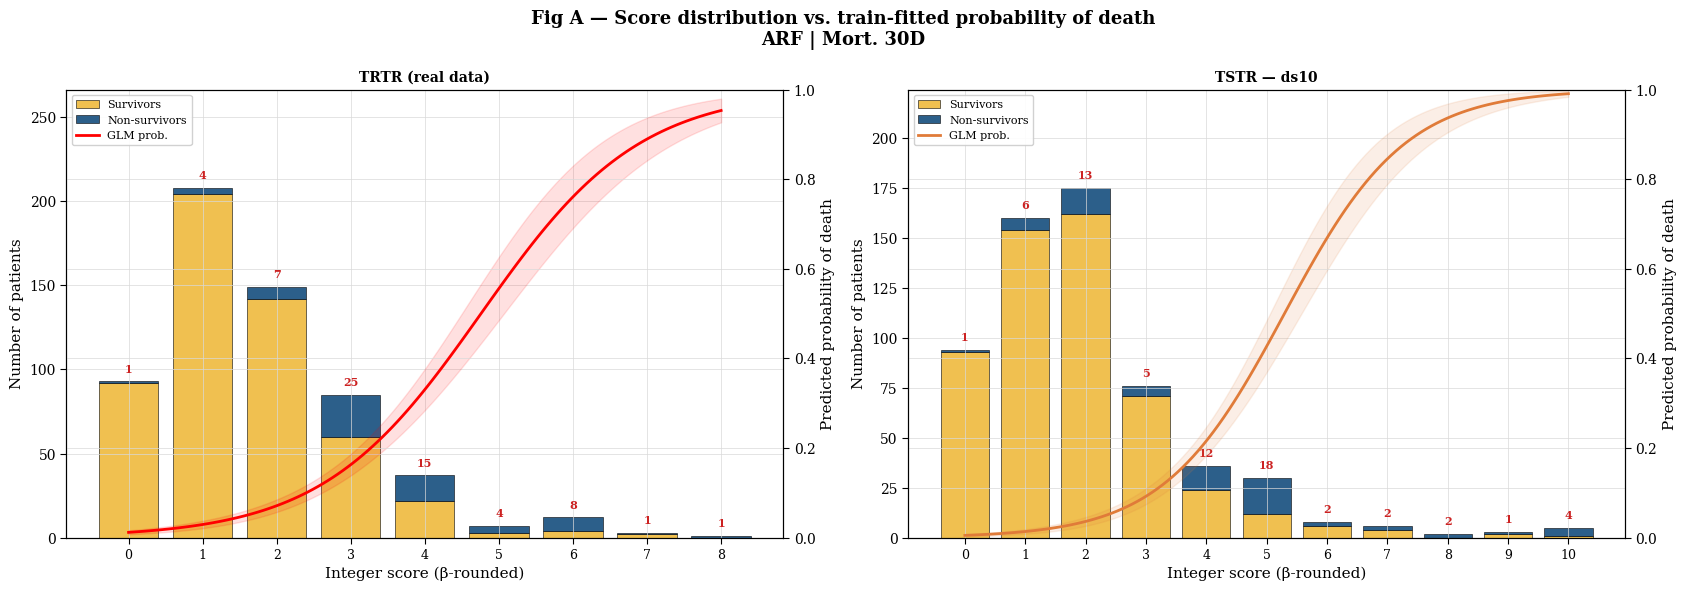

In [ ]:
# ── TSTR 8b-2 — FIG A: SCORE DISTRIBUTION vs PROBABILITY OF DEATH ───────────
"""
PURPOSE: Side-by-side stacked bar chart (integer score × patient counts) overlaid
         with a GLM logistic probability curve for both TRTR and the representative
         TSTR replica.

The GLM curve is fitted on the corresponding TRAINING partition:
- TRTR: real training scores and outcomes.
- TSTR: synthetic training scores and outcomes.

The real test set is used only for the observed bar counts.
"""

# ── Local colour aliases (NB4-style mortality plots) ─────────────────────────
_SURV_COL  = '#F0C050'              # gold — survivors bar fill
_NSURV_COL = TFG_COLORS['primary']  # dark blue — non-survivors bar fill
_DEATH_ANN = '#CC2222'              # red — death count annotation


def _plot_score_vs_death(ax_bar, ax_prob, scores_test, y_test_plot,
                         scores_train, y_train_fit, title, prob_color):
    """Stacked test-set bars + train-fitted GLM probability overlay."""
    scores_test = np.asarray(scores_test)
    y_test_plot = np.asarray(y_test_plot)
    score_vals = np.arange(scores_test.min(), scores_test.max() + 1)
    c_surv = np.array([((y_test_plot == 0) & (scores_test == s)).sum()
                       for s in score_vals])
    c_dead = np.array([((y_test_plot == 1) & (scores_test == s)).sum()
                       for s in score_vals])
    totals = c_surv + c_dead

    y_max = max(totals.max(), 1)
    ax_bar.set_ylim(0, y_max * 1.28)
    x_pos = np.arange(len(score_vals))

    ax_bar.bar(x_pos, c_surv, color=_SURV_COL,
               edgecolor='black', linewidth=0.4, label='Survivors')
    ax_bar.bar(x_pos, c_dead, bottom=c_surv, color=_NSURV_COL,
               edgecolor='black', linewidth=0.4, label='Non-survivors')

    for xi, (nd, tot) in enumerate(zip(c_dead, totals)):
        if nd > 0:
            ax_bar.text(xi, tot + y_max * 0.02, str(int(nd)),
                        ha='center', va='bottom', fontsize=8,
                        color=_DEATH_ANN, fontweight='bold')

    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels([str(s) for s in score_vals], fontsize=9)
    ax_bar.set_xlabel('Integer score (β-rounded)')
    ax_bar.set_ylabel('Number of patients')
    ax_bar.set_title(title, fontweight='bold', fontsize=10)

    # GLM logistic overlay fitted on TRAIN, predicted across the TEST score range
    try:
        train_X = sm.add_constant(np.asarray(scores_train, dtype=float),
                                  has_constant='add')
        glm = sm.GLM(np.asarray(y_train_fit).astype(int), train_X,
                     family=sm.families.Binomial()).fit()
        newx = np.linspace(scores_test.min(), scores_test.max(), 120)
        newx_c = sm.add_constant(newx, has_constant='add')
        prd = np.asarray(glm.predict(newx_c))
        x_interp = np.interp(newx, score_vals, x_pos)
        ax_prob.plot(x_interp, prd, '-', color=prob_color, lw=2, label='GLM prob.')

        try:
            se_prd = glm.get_prediction(newx_c).se_mean
            ax_prob.fill_between(x_interp,
                                 np.clip(prd - 1.96 * se_prd, 0, 1),
                                 np.clip(prd + 1.96 * se_prd, 0, 1),
                                 alpha=0.12, color=prob_color)
        except Exception:
            pass
    except Exception as _e:
        print(f'  ⚠ GLM overlay failed ({title}): {_e}')

    ax_prob.set_ylabel('Predicted probability of death')
    ax_prob.set_ylim(0, 1.0)
    ax_prob.set_yticks(np.arange(0, 1.05, 0.2))


fig_a, axes_a = plt.subplots(1, 2, figsize=(17, 6))
for ax, sc_test, y_train_fit, sc_train, lbl, col in [
    (axes_a[0], test_scores_real_int, y_train_real, train_scores_real_int,
     'TRTR (real data)', 'red'),
    (axes_a[1], test_scores_repr, y_repr_train, train_scores_repr,
     f'TSTR — {repr_key}', TFG_COLORS[GENERATOR]),
]:
    ax2 = ax.twinx()
    _plot_score_vs_death(ax, ax2, sc_test, y_test, sc_train, y_train_fit, lbl, col)
    ln1, lb1 = ax.get_legend_handles_labels()
    ln2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(ln1 + ln2, lb1 + lb2, loc='upper left', fontsize=8)

fig_a.suptitle(
    f'Fig A — Score distribution vs. train-fitted probability of death\n'
    f'{GENERATOR} | {TARGET_COL}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'score_vs_death_prob.png'), dpi=150)
plt.show()


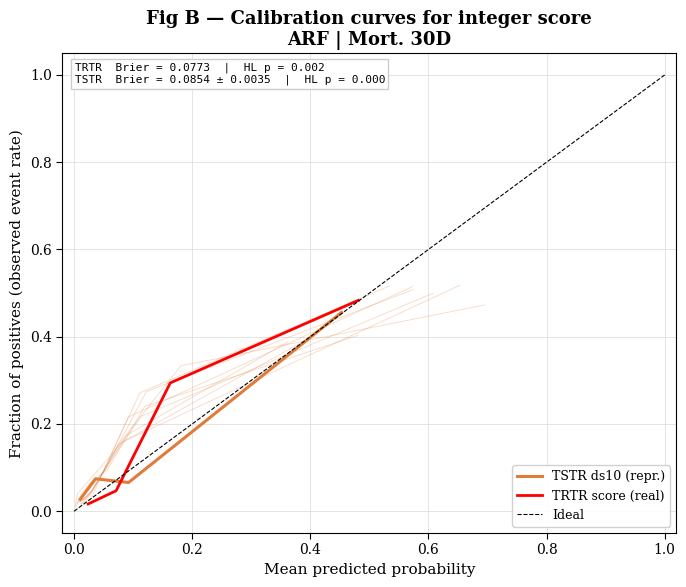

In [ ]:
# ── TSTR 8b-3 — FIG B: CALIBRATION CURVES ───────────────────────────────────
"""
PURPOSE: Compare score-calibrated predicted probabilities against observed event
         rates for all TSTR replicas, the TRTR baseline, and the representative
         replica.

All probabilities come from a score-to-probability GLM fitted on the corresponding
training partition, not on the real test set.
"""

fig_b, ax_b = plt.subplots(figsize=(7, 6))

# All TSTR score-calibrated probabilities — faint lines; representative — bold
for i_r, prob_s in enumerate(tstr_score_probs):
    n_bins_s = max(5, min(10, len(np.unique(np.round(prob_s, 3))) // 2))
    fp_s, mp_s = sklearn_calibration_curve(
        y_test, prob_s, n_bins=n_bins_s, strategy='quantile')
    is_repr = (i_r == repr_idx)
    ax_b.plot(mp_s, fp_s,
              color=TFG_COLORS[GENERATOR],
              lw=2.2 if is_repr else 0.7,
              alpha=1.0 if is_repr else 0.25,
              label=f'TSTR {repr_key} (repr.)' if is_repr else None)

# TRTR baseline — integer score calibrated on real train
n_bins_r = max(5, min(10, len(np.unique(np.round(p_test_score_real, 3))) // 2))
fp_r, mp_r = sklearn_calibration_curve(
    y_test, p_test_score_real, n_bins=n_bins_r, strategy='quantile')
ax_b.plot(mp_r, fp_r, color='red', lw=2, label='TRTR score (real)')
ax_b.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Ideal')

# Statistics inset (Brier + Hosmer-Lemeshow)
mean_brier = tstr_df['Brier_SCORE'].mean()
sd_brier   = tstr_df['Brier_SCORE'].std()
mean_hlp   = tstr_df['HL_p_SCORE'].mean()
inset_txt  = (f"TRTR  Brier = {brier_real_score:.4f}  |  HL p = {hl_p_real_score:.3f}\n"
              f"TSTR  Brier = {mean_brier:.4f} ± {sd_brier:.4f}"
              f"  |  HL p = {mean_hlp:.3f}")
ax_b.text(0.02, 0.98, inset_txt, transform=ax_b.transAxes, fontsize=8,
          va='top', fontfamily='monospace',
          bbox=dict(boxstyle='square,pad=0.3', facecolor='white',
                    edgecolor='#cccccc'))

ax_b.set_xlabel('Mean predicted probability')
ax_b.set_ylabel('Fraction of positives (observed event rate)')
ax_b.set_xlim(-0.02, 1.02)
ax_b.set_ylim(-0.05, 1.05)
ax_b.legend(fontsize=9, loc='lower right')
ax_b.set_title(f'Fig B — Calibration curves for integer score\n{GENERATOR} | {TARGET_COL}',
               fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'calibration_curves_score.png'), dpi=150)
plt.show()


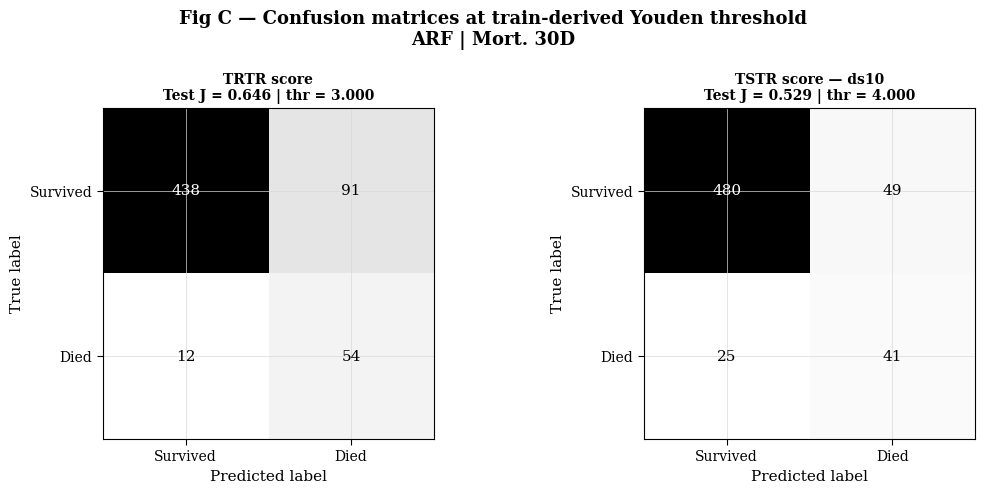

TRTR score — Classification Report (train-derived Youden threshold):
              precision    recall  f1-score   support

    Survived       0.97      0.83      0.89       529
        Died       0.37      0.82      0.51        66

    accuracy                           0.83       595
   macro avg       0.67      0.82      0.70       595
weighted avg       0.91      0.83      0.85       595

TSTR score (ds10) — Classification Report (train-derived Youden threshold):
              precision    recall  f1-score   support

    Survived       0.95      0.91      0.93       529
        Died       0.46      0.62      0.53        66

    accuracy                           0.88       595
   macro avg       0.70      0.76      0.73       595
weighted avg       0.90      0.88      0.88       595



In [ ]:
# ── TSTR 8b-4 — FIG C: CONFUSION MATRICES + CLASSIFICATION REPORTS ─────────
"""
PURPOSE: Confusion matrices at the train-derived Youden threshold for TRTR and
         the representative TSTR replica.

The thresholds are selected on training data:
- TRTR threshold: real training integer scores.
- TSTR threshold: synthetic training integer scores.

The real test set is used only to compute the final confusion matrices and
classification reports.
"""

y_pred_repr_cm = (test_scores_repr >= repr_row['Youden_thr_SCORE']).astype(int)

fig_c, axes_c = plt.subplots(1, 2, figsize=(11, 5))
for ax_cm, y_pred_cm, lbl_cm in [
    (axes_c[0], y_pred_real_cm,
     f'TRTR score\nTest J = {youden_j_real:.3f} | '
     f'thr = {youden_thr_r:.3f}'),
    (axes_c[1], y_pred_repr_cm,
     f'TSTR score — {repr_key}\nTest J = {repr_row["Youden_J_SCORE_test"]:.3f} | '
     f'thr = {repr_row["Youden_thr_SCORE"]:.3f}'),
]:
    cm_arr = confusion_matrix(y_test, y_pred_cm, labels=[0, 1])
    ConfusionMatrixDisplay(cm_arr, display_labels=['Survived', 'Died']).plot(
        ax=ax_cm, colorbar=False, cmap='Greys')
    ax_cm.set_title(lbl_cm, fontsize=10, fontweight='bold')

fig_c.suptitle(
    f'Fig C — Confusion matrices at train-derived Youden threshold\n'
    f'{GENERATOR} | {TARGET_COL}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices_score.png'), dpi=150)
plt.show()

# ── Classification reports ────────────────────────────────────────────────────
print('TRTR score — Classification Report (train-derived Youden threshold):')
print(classification_report(y_test, y_pred_real_cm,
                            target_names=['Survived', 'Died'], zero_division=0))

print(f'TSTR score ({repr_key}) — Classification Report (train-derived Youden threshold):')
print(classification_report(y_test, y_pred_repr_cm,
                            target_names=['Survived', 'Died'], zero_division=0))


## **9. Comparative Summary**

### Purpose

This cell consolidates all utility metrics into a single summary row for the
current `GENERATOR` × `TARGET_COL` combination. The row is saved to
`utility_summary.csv`.

TSTR metrics are reported as **mean ± SD across the 10 synthetic replicas**,
reflecting inter-replica variability. The primary downstream endpoint is the
**β-rounded integer score**. Ridge probability-model metrics are included as
supporting diagnostics.

### Interpretation

- Score-level TSTR answers: *Can synthetic data reproduce the NB4 clinical risk
  scale development pipeline and generalise to unseen real patients?*
- Ridge-level TSTR answers: *Can synthetic data train the underlying probability
  model?*

The two are related but not interchangeable.


In [ ]:
# ── COMPARATIVE SUMMARY ───────────────────────────────────────────────────────
"""
PURPOSE: Consolidate all utility metrics into a single summary table for this
         generator–outcome combination.

The primary TSTR endpoint is the β-rounded integer score. Ridge metrics are
reported separately as supporting diagnostics.
"""

summary_all = {
    'Generator':           GENERATOR,
    'Outcome':             TARGET_COL,

    # ── General utility ───────────────────────────────────────────────────
    'pMSE_mean':           pmse_vals.mean(),
    'pMSE_sd':             pmse_vals.std(),

    # ── Variable selection agreement ──────────────────────────────────────
    'AIC_full_agree':      (freq_df.loc[freq_df['in_real'], 'frequency'].min()
                            if freq_df['in_real'].any() else np.nan),

    # ── Coefficient replicability (El Emam) ───────────────────────────────
    'CI_overlap_mean':     rep_df['ci_overlap'].mean(),
    'DecisionAgree_all':   bool(rep_df['decision_agree'].all()),
    'EmpiricalSE_mean':    rep_df['empirical_SE'].mean(),

    # ── Primary endpoint: integer β-rounded score ─────────────────────────
    'AUC_ROC_SCORE_TSTR_mean':   tstr_df['AUC_ROC_SCORE'].mean(),
    'AUC_ROC_SCORE_TSTR_sd':     tstr_df['AUC_ROC_SCORE'].std(),
    'AUC_ROC_SCORE_TRTR':        auc_roc_real_score,
    'AUC_PR_SCORE_TSTR_mean':    tstr_df['AUC_PR_SCORE'].mean(),
    'AUC_PR_SCORE_TSTR_sd':      tstr_df['AUC_PR_SCORE'].std(),
    'AUC_PR_SCORE_TRTR':         auc_pr_real_score,
    'Brier_SCORE_TSTR_mean':     tstr_df['Brier_SCORE'].mean(),
    'Brier_SCORE_TSTR_sd':       tstr_df['Brier_SCORE'].std(),
    'Brier_SCORE_TRTR':          brier_real_score,
    'HL_p_SCORE_TSTR_mean':      tstr_df['HL_p_SCORE'].mean(),
    'HL_p_SCORE_TSTR_sd':        tstr_df['HL_p_SCORE'].std(),
    'HL_p_SCORE_TRTR':           hl_p_real_score,
    'Sensitivity_SCORE_TSTR_mean': tstr_df['Sensitivity_SCORE'].mean(),
    'Sensitivity_SCORE_TSTR_sd':   tstr_df['Sensitivity_SCORE'].std(),
    'Specificity_SCORE_TSTR_mean': tstr_df['Specificity_SCORE'].mean(),
    'Specificity_SCORE_TSTR_sd':   tstr_df['Specificity_SCORE'].std(),
    'Youden_J_SCORE_TSTR_mean':  tstr_df['Youden_J_SCORE_test'].mean(),
    'Youden_J_SCORE_TSTR_sd':    tstr_df['Youden_J_SCORE_test'].std(),
    'Youden_J_SCORE_TRTR':       youden_j_score_real_test,

    # ── Supporting endpoint: Ridge probability model ──────────────────────
    'AUC_ROC_RIDGE_TSTR_mean':   tstr_df['AUC_ROC_RIDGE'].mean(),
    'AUC_ROC_RIDGE_TSTR_sd':     tstr_df['AUC_ROC_RIDGE'].std(),
    'AUC_ROC_RIDGE_TRTR':        auc_roc_real_ridge,
    'Brier_RIDGE_TSTR_mean':     tstr_df['Brier_RIDGE'].mean(),
    'Brier_RIDGE_TSTR_sd':       tstr_df['Brier_RIDGE'].std(),
    'Brier_RIDGE_TRTR':          brier_real_ridge,

    # ── Integer scoring diagnostics ───────────────────────────────────────
    'Max_Score_repr':      max_score_repr,
    'Max_Score_TRTR':      max_score_real,
    'Repr_replica':        repr_key,
}

pd.Series(summary_all).to_csv(os.path.join(OUTPUT_DIR, 'utility_summary.csv'))
print("Summary saved to:", OUTPUT_DIR)
print(pd.Series(summary_all).to_string())


Summary saved to: /content/drive/MyDrive/Colab Notebooks/TFG/EVALUATION/NB9_UTILITY/ARF_Mort30D/
Generator                            ARF
Outcome                        Mort. 30D
pMSE_mean                       0.369842
pMSE_sd                         0.008486
AIC_full_agree                       0.7
CI_overlap_mean                 0.714007
DecisionAgree_all                  False
EmpiricalSE_mean                0.102652
AUC_ROC_SCORE_TSTR_mean         0.825766
AUC_ROC_SCORE_TSTR_sd           0.025285
AUC_ROC_SCORE_TRTR               0.86123
AUC_PR_SCORE_TSTR_mean          0.397844
AUC_PR_SCORE_TSTR_sd            0.034732
AUC_PR_SCORE_TRTR               0.417824
Brier_SCORE_TSTR_mean           0.085396
Brier_SCORE_TSTR_sd             0.003472
Brier_SCORE_TRTR                0.077336
HL_p_SCORE_TSTR_mean            0.000087
HL_p_SCORE_TSTR_sd              0.000193
HL_p_SCORE_TRTR                 0.001709
Sensitivity_SCORE_TSTR_mean     0.660606
Sensitivity_SCORE_TSTR_sd       0.076328
S

## **10. Conclusions**

Results are saved to `utility_summary.csv` and detailed per-metric CSV files in
`OUTPUT_DIR`.

### Interpretation thresholds

| Metric | Acceptable range | Ideal |
|--------|-----------------|-------|
| `pMSE_norm` | < 0.20 | → 0 |
| `AIC_full_agree` | ≥ 0.70 | 1.00 |
| `CI_overlap_mean` | ≥ 0.80 | 1.00 |
| `DecisionAgree_all` | True | True |
| `AUC_ROC_SCORE_TSTR / TRTR` ratio | ≥ 0.90 | ≥ 0.95 |
| `Brier_SCORE_TSTR` | ≤ `Brier_SCORE_TRTR × 1.15` | ≈ `Brier_SCORE_TRTR` |
| `HL_p_SCORE_TSTR` | > 0.05 | > 0.10 |
| `Youden_J_SCORE_TSTR / TRTR` ratio | ≥ 0.85 | ≥ 0.92 |
| `Max_Score_repr` vs. `Max_Score_TRTR` | Within ± 2 pts | Equal |

### Workflow for cross-generator comparison

1. Run with `GENERATOR = 'ARF'`  → saves to `NB9_UTILITY/ARF_{TARGET_SAFE}/`
2. Run with `GENERATOR = 'CTABGAN'` → saves to `NB9_UTILITY/CTABGAN_{TARGET_SAFE}/`
3. Merge both `utility_summary.csv` files on `Outcome` for a side-by-side table.

### Methodological notes

- The real training set is reconstructed from the exported generation cohorts
  in `GENERATION/DATASET_<GENERATOR>/cohorts/`; it is not re-split inside NB9.
- All final evaluations use `dataset_TEST.csv`, a real partition not used to
  train the generators.
- Clinical cutpoints in Section 8 are fixed from NB4 and never re-estimated on
  synthetic data.
- Youden thresholds are selected on the corresponding training partition:
  synthetic train for TSTR and real train for TRTR.
- The Hosmer-Lemeshow test is sensitive to sample size: a non-significant
  p-value means no statistical evidence of poor calibration, not proof of
  perfect calibration.
